# Predicting protein abundance from RNA-seq — a broad model screen

**Author:** Kristina Gagalova  ·  **Project:** IntegrateProtRNA

## The question

Earlier notebooks in this project asked a *dimensionality-reduction* question:
which low-rank representation (PCA / PLS / autoencoder) best summarises the two
omics layers. This notebook asks a deliberately broader and more direct
**supervised** question:

> **Given RNA-seq, can we predict protein abundance — and which machine-learning
> model does it best, once treatment and timepoint are taken into account?**

Rather than committing to one model family a priori, we screen **40 regressors**
with [`LazyPredict`](https://github.com/shankarpandala/lazypredict), which fits
every scikit-learn regressor through a common preprocessing pipeline and returns
a ranked leaderboard. Everything downstream uses standard `scikit-learn`
functions — no hand-rolled estimators, no custom gradient code.

---

## The one design constraint that shapes everything

From `docs/PIPELINE.md`:

> RNA and protein are measured on **different biological material** (Case B,
> unmatched). The two layers share no samples. **The shared dimension is the
> design cell** (treatment × timepoint).

This is not a detail — it dictates the unit of analysis:

* We **cannot** pair sample `LH10`'s RNA with sample `LH10`'s protein. The
  column names coincide across the two matrices, but the underlying material
  does not.
* We **can** pair the *design-cell mean* of RNA with the *design-cell mean* of
  protein, because both are estimated from three replicates drawn from the same
  experimental condition.

So the modelling unit is **one (gene, design cell) pair**: 2 treatments ×
4 timepoints = 8 design cells per variety, and a few thousand genes with both
layers measured. That gives tens of thousands of rows — enough for a genuine
ML screen, unlike the 8 pseudo-samples available to the sample-level methods.

## What this notebook does

| § | Step | Why |
|:--|:--|:--|
| 1 | Setup | Imports, config, seed |
| 2 | Load and QC both layers | CPM/log2 for RNA, log2 + median-normalise for protein |
| 3 | Aggregate to design cells | The only valid pairing unit under Case B |
| 4 | Feature engineering | Cognate RNA + gene context + condition + kinetics |
| 5 | Evaluation protocol | Grouped splits, leakage control, why `R²` is comparable |
| 6 | **Task A** — predict protein *level* | 40-model screen, unseen genes |
| 7 | **Task B** — predict protein *response* | 40-model screen, unseen genes |
| 8 | **Does the baseline matter?** | Five reference schemes; t=0 and the control arm tested, not assumed |
| 9 | **Does the RNA universe matter?** | Full ~128k transcriptome vs the ~6k protein-matched subset |
| 10 | **Leave-one-condition-out, done properly** | Nested model selection and fold-internal features |
| 11 | Feature ablation | Do treatment and timepoint actually add predictive value? |
| 12 | Winner deep-dive | Per-condition `R²`, permutation importance, calibration |
| 13 | Replication in Norin | Does the same model win in the second variety? |
| 14 | What is safe to claim | |

**Two tasks, not one.** Task A predicts the protein's *absolute* level. Much of
that is driven by gene identity — abundant transcripts make abundant proteins —
which is real but not very interesting biologically. Task B removes the gene's
own baseline and asks the harder question this project actually cares about:
**can RNA predict how the protein responds to treatment over time?**

---

## 1. Setup

In [1]:
# Standard scientific Python stack only — every model and metric below comes
# from scikit-learn, and the model screen from LazyPredict.
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from lazypredict.Supervised import LazyRegressor
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import (HistGradientBoostingRegressor,
                              RandomForestRegressor)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_val_predict
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# LazyPredict fits 40 models, several of which are a poor match for this data and
# emit convergence warnings. They are silenced for readability; the leaderboard
# still shows their (bad) scores, which is the honest way to report them.
warnings.filterwarnings("ignore")

SEED = 20260826            # single seed, used everywhere that randomness enters
rng = np.random.RandomState(SEED)

DATA = Path("../../data/real")          # notebook lives in analysis/predictions/
FIGS = Path("figs"); FIGS.mkdir(exist_ok=True)

# The experiment: 2 treatments x 4 timepoints x 3 replicates, per variety.
# Timepoint labels t0..t3 map to hours as documented in config/config.yaml.
TIME_H = {"t0": 0, "t1": 6, "t2": 24, "t3": 48}
TREAT_LABEL = {"T0": "Control", "T1": "Treated"}
BASELINE_CELL = "T0_t0"    # untreated, time zero — the reference for Task B

# LazyPredict screens on a capped random subsample so that the O(n^2)/O(n^3)
# models (SVR, NuSVR, GaussianProcess, KernelRidge) stay tractable. The winner is
# then refit properly in §10. Screening on a subsample is standard practice and
# is stated explicitly rather than hidden.
SWEEP_CAP = 4000

print(f"pandas {pd.__version__} | numpy {np.__version__}")
import sklearn, lazypredict
print(f"scikit-learn {sklearn.__version__} | lazypredict {lazypredict.__version__}")

pandas 2.3.3 | numpy 2.2.6
scikit-learn 1.7.2 | lazypredict 0.3.0


In [2]:
# --- Plot styling -------------------------------------------------------
# A small fixed palette, assigned by role (not cycled). Blue is the single
# sequential hue for magnitude; blue/orange are the two categorical slots used
# for Control vs Treated; blue-to-red diverging is reserved for signed values.
C_BLUE, C_ORANGE, C_AQUA, C_RED = "#2a78d6", "#eb6834", "#1baf7a", "#e34948"
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
TREAT_COLOR = {"Control": C_BLUE, "Treated": C_ORANGE}

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120, "figure.facecolor": "white",
    "axes.facecolor": "white", "axes.edgecolor": GRID, "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "font.size": 9,
    "axes.titlesize": 10.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "legend.frameon": False,
})


def tidy(ax, xlabel=None, ylabel=None, title=None, subtitle=None,
         xgrid=True, ygrid=False):
    """Apply the recessive-chrome conventions: no top/right spine, one grid axis.

    `subtitle` is placed a fixed number of *points* above the axes and the title
    is padded above it, so the two never collide regardless of figure size.
    """
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.grid(axis="x", visible=xgrid)
    ax.grid(axis="y", visible=ygrid)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    if subtitle:
        ax.annotate(subtitle, xy=(0, 1), xycoords="axes fraction",
                    xytext=(0, 5), textcoords="offset points",
                    ha="left", va="bottom", fontsize=8.5, color=MUTED)
    if title:
        ax.set_title(title, pad=22 if subtitle else 10)
    return ax

---

## 2. Load and QC the two layers

Both layers arrive as feature × sample matrices with the same 24 sample IDs
per variety, plus a metadata table giving each sample's treatment, timepoint and
replicate.

**RNA-seq** are raw counts. Standard treatment: counts → CPM (library-size
normalisation) → `log2(CPM + 1)`, keeping genes expressed above 1 CPM in at
least 3 samples (`config/config.yaml`: `rna_min_count`, `rna_min_samples`).

**Protein** are raw MS intensities in which **`0` encodes "not detected"**, not
"zero abundance" — so zeros become `NaN` rather than being log-transformed.
Then `log2`, then median normalisation across samples (`prot_normalisation:
median` in the config), which removes per-run loading differences.

In [3]:
def load_variety(variety):
    """Read the three files for one variety and attach design metadata.

    Returns raw (unnormalised) matrices plus a sample table carrying the
    design-cell label. Columns of both matrices are reordered to match `meta`.
    """
    rna = pd.read_csv(DATA / f"{variety}-rnaseq.csv", index_col=0)
    prot = pd.read_csv(DATA / f"{variety}-prot.csv", index_col=0)
    meta = pd.read_csv(DATA / f"{variety}_metadata.csv", index_col=0)

    # Design cell = treatment x timepoint. This is the unit at which the two
    # layers can legitimately be paired under the Case B design.
    meta["time_h"] = meta["timepoint"].map(TIME_H)
    meta["cell"] = meta["treatment"] + "_" + meta["timepoint"]

    return rna[meta.index], prot[meta.index], meta


def normalise_rna(rna, min_cpm=1.0, min_samples=3):
    """Counts -> CPM -> log2, dropping genes that are lowly expressed everywhere."""
    cpm = rna / rna.sum() * 1e6                      # library-size normalisation
    keep = (cpm > min_cpm).sum(axis=1) >= min_samples
    return np.log2(cpm.loc[keep] + 1)


def rna_universe(variety, universe="full"):
    """Normalise the RNA layer over a chosen gene universe.

    The choice matters because CPM is a *relative* measure: dividing by the
    library total makes every gene's value depend on which genes are counted in
    that total. §9 tests whether it changes the predictions.

    universe="full"    : all genes in the RNA-seq (the default; ~128k genes)
    universe="matched" : only genes that also have a protein measurement, with
                         library sizes recomputed within that subset
    """
    rna, prot, _ = RAW[variety]
    if universe == "matched":
        rna = rna.loc[rna.index.intersection(prot.index)]
    elif universe != "full":
        raise ValueError(f"unknown universe: {universe}")
    return normalise_rna(rna)


def normalise_prot(prot):
    """0 (= not detected) -> NaN, then log2, then median-centre each sample."""
    lp = np.log2(prot.replace(0, np.nan))
    # Median normalisation: shift every sample to a common median, preserving the
    # overall intensity scale (so values stay interpretable as log2 intensities).
    return lp - lp.median() + lp.median().median()

In [4]:
# Load both varieties up front; Cadenza is the primary analysis, Norin the
# independent replication in §11.
RAW = {v: load_variety(v) for v in ("cadenza", "norin")}

for v, (rna, prot, meta) in RAW.items():
    lr, lp = normalise_rna(rna), normalise_prot(prot)
    print(f"{v:8s}  RNA {rna.shape[0]:>7,} genes -> {lr.shape[0]:>6,} after filter"
          f"   |  protein {prot.shape[0]:>5,} groups, "
          f"{prot.eq(0).sum().sum() / prot.size:.1%} not detected")

# The protein IDs are a clean 1:1 match to gene IDs in this dataset (verified
# below), so the "Universe B" 1:1 mapping of docs/PIPELINE.md is the whole set —
# no bipartite-graph resolution is needed here.
for v in RAW:
    m = pd.read_csv(DATA / f"{v}_protein_gene_mapping.csv")
    print(f"{v:8s}  mapping rows {len(m):,}, identity protein_id == gene_id: "
          f"{(m.protein_id == m.gene_id).all()}")

cadenza   RNA 128,544 genes -> 49,315 after filter   |  protein 6,105 groups, 25.1% not detected
norin     RNA 145,065 genes -> 49,176 after filter   |  protein 5,879 groups, 23.8% not detected
cadenza   mapping rows 6,105, identity protein_id == gene_id: True
norin     mapping rows 5,879, identity protein_id == gene_id: True


---

## 3. Aggregate to design cells

This is the step that makes the analysis valid under Case B. For each gene we
compute, **within each of the 8 design cells**, the mean across the 3 replicates
— separately for RNA and for protein. The resulting two 8-column matrices *are*
comparable, because both describe the same 8 experimental conditions.

Two filters follow the project's existing QC policy:

* A protein cell mean is kept only if the protein was detected in **≥ 2 of 3
  replicates** of that cell (`prot_min_valid_in_a_group: 2`). This is the
  "≥ n valid in at least one design cell" logic applied per cell, so that a
  single stray detection does not become a data point.
* A gene is kept only if it has a valid protein value in **≥ 6 of 8 cells**, so
  that per-gene trajectory features are well determined.

We also retain the **within-cell replicate SD** of RNA, which is a per-observation
measure of how reliably that transcript was quantified — a legitimate predictor,
and one that only uses the RNA layer.

In [5]:
def to_design_cells(variety, lrna=None, min_valid_per_cell=2, min_valid_cells=6):
    """Collapse replicates to design-cell means for both layers.

    `lrna` lets a caller supply an alternative RNA normalisation (see §9);
    it defaults to the full-transcriptome universe.

    Returns
    -------
    rna_cell   : genes x 8 — mean log2 CPM per design cell
    rna_rep_sd : genes x 8 — within-cell replicate SD of log2 CPM (reliability)
    prot_cell  : genes x 8 — mean log2 intensity per cell, NaN where under-detected
    cellmeta   : 8 x n — treatment / timepoint / hours for each design cell
    """
    rna, prot, meta = RAW[variety]
    if lrna is None:
        lrna = rna_universe(variety, "full")
    lprot = normalise_prot(prot)

    # Restrict to genes measured in BOTH layers (the 1:1 protein-gene universe).
    genes = lprot.index.intersection(lrna.index)
    lrna, lprot = lrna.loc[genes], lprot.loc[genes]

    cells = meta["cell"].unique()
    cols = {c: meta.index[meta.cell == c] for c in cells}       # samples per cell

    rna_cell = pd.DataFrame({c: lrna[s].mean(axis=1) for c, s in cols.items()})
    rna_rep_sd = pd.DataFrame({c: lrna[s].std(axis=1) for c, s in cols.items()})

    # Protein: require >=2 valid replicates before trusting a cell mean.
    n_valid = pd.DataFrame({c: lprot[s].notna().sum(axis=1) for c, s in cols.items()})
    prot_cell = pd.DataFrame({c: lprot[s].mean(axis=1) for c, s in cols.items()})
    prot_cell = prot_cell.mask(n_valid < min_valid_per_cell)

    keep = prot_cell.notna().sum(axis=1) >= min_valid_cells
    cellmeta = (meta.drop_duplicates("cell").set_index("cell")
                    [["treatment", "timepoint", "time_h"]])

    return (rna_cell[keep], rna_rep_sd[keep], prot_cell[keep],
            cellmeta.loc[list(cells)])


CELLS_DATA = {v: to_design_cells(v) for v in RAW}
for v, (rc, rsd, pc, cm) in CELLS_DATA.items():
    print(f"{v:8s}  {pc.shape[0]:>5,} genes x {pc.shape[1]} design cells   "
          f"({pc.isna().sum().sum():,} protein cell-means dropped by the validity filter)")

CELLS_DATA["cadenza"][3]   # the 8 design cells

cadenza   3,926 genes x 8 design cells   (1,130 protein cell-means dropped by the validity filter)
norin     3,726 genes x 8 design cells   (1,067 protein cell-means dropped by the validity filter)


,treatment,timepoint,time_h
cell,,,
T0_t0,T0,t0,0
T1_t0,T1,t0,0
T0_t1,T0,t1,6
T1_t1,T1,t1,6
T0_t2,T0,t2,24
T1_t2,T1,t2,24
T0_t3,T0,t3,48
T1_t3,T1,t3,48


---

## 4. Feature engineering

Every predictor below is derived **from the RNA layer or the design alone** —
nothing on the right-hand side ever touches the protein measurements. That is
what makes the exercise a genuine prediction rather than a re-description.

The features fall into four groups, chosen to reflect what the project's kinetics
work established (`docs/PIPELINE.md`): protein level depends not just on the
transcript's current level, but on its **history**, because protein turnover
integrates mRNA over time.

| Group | Feature | Meaning |
|:--|:--|:--|
| **Cognate signal** | `rna` | log2 CPM of *this* gene in *this* design cell |
| | `rna_lfc` | `rna` minus the gene's value in the `T0_t0` baseline cell |
| **Gene context** | `rna_gene_mean` | the gene's mean log2 CPM over all 8 cells |
| | `rna_gene_sd` | its SD over the 8 cells — how dynamic the transcript is |
| | `rna_base` | its log2 CPM in the `T0_t0` baseline cell |
| | `rna_rep_sd` | within-cell replicate SD — quantification reliability |
| **Condition** | `trt` | 0 = Control, 1 = Treated |
| | `time_h` | 0, 6, 24 or 48 hours |
| **Kinetics / contrasts** | `rna_vs_lag1` | change in `rna` since the *previous* timepoint, same treatment |
| | `rna_trt_effect` | `rna` minus the matched Control cell at the same timepoint |

`rna_vs_lag1` is the notebook's nod to turnover: a protein that responds slowly
tracks the *recent history* of its transcript, not its instantaneous level.
`rna_trt_effect` isolates the treatment contrast at each timepoint, which is
exactly the quantity the limma design in `R/04_univariate_temporal_de.R` tests.

In [6]:
def build_features(variety, cells=None):
    """Assemble the tidy (gene, design cell) modelling table for one variety.

    One row per gene per design cell. All predictors are RNA- or design-derived;
    the protein columns are targets only. `cells` lets §9 pass a design-cell set
    built from a different RNA normalisation.
    """
    rna_cell, rna_rep_sd, prot_cell, cellmeta = cells or CELLS_DATA[variety]

    # --- long format: one row per (gene, cell) ---------------------------
    d = rna_cell.stack().rename("rna").to_frame()
    d.index.names = ["gene", "cell"]
    d["rna_rep_sd"] = rna_rep_sd.stack()
    # reindex keeps the NaN protein cells as explicit missing targets
    d["prot"] = prot_cell.stack(dropna=False).reindex(d.index)
    d = d.join(cellmeta, on="cell").reset_index()

    # --- gene context: summaries over the 8 cells ------------------------
    g = d.groupby("gene")["rna"]
    d["rna_gene_mean"] = g.transform("mean")
    d["rna_gene_sd"] = g.transform("std")

    # --- baseline (T0_t0) values, per gene, in both layers ---------------
    base = d[d.cell == BASELINE_CELL].set_index("gene")
    d = d.join(base["rna"].rename("rna_base"), on="gene")
    d = d.join(base["prot"].rename("prot_base"), on="gene")
    d["rna_lfc"] = d["rna"] - d["rna_base"]        # predictor
    d["prot_lfc"] = d["prot"] - d["prot_base"]     # Task B target

    # --- kinetics: RNA change since the previous timepoint ---------------
    # Pivot to gene x time within each treatment arm, shift one timepoint along.
    wide = d.pivot_table(index=["gene", "treatment"], columns="time_h", values="rna")
    lag1 = wide.shift(1, axis=1).stack().rename("rna_lag1")
    d = d.join(lag1, on=["gene", "treatment", "time_h"])
    # At t = 0 there is no previous timepoint; "no change since before" = 0.
    d["rna_vs_lag1"] = (d["rna"] - d["rna_lag1"]).fillna(0.0)

    # --- design contrast: treated minus its matched control cell ---------
    ctrl = (d[d.treatment == "T0"].set_index(["gene", "time_h"])["rna"]
              .rename("rna_ctrl"))
    d = d.join(ctrl, on=["gene", "time_h"])
    d["rna_trt_effect"] = d["rna"] - d["rna_ctrl"]

    d["trt"] = (d["treatment"] == "T1").astype(int)
    d["condition"] = d["treatment"].map(TREAT_LABEL) + " " + d["time_h"].astype(str) + "h"
    return d


FEATURES = build_features("cadenza")
print(f"{len(FEATURES):,} (gene, cell) rows | {FEATURES.gene.nunique():,} genes "
      f"| {FEATURES.cell.nunique()} design cells")
FEATURES.head(8)

31,408 (gene, cell) rows | 3,926 genes | 8 design cells


,gene,cell,rna,rna_rep_sd,prot,treatment,timepoint,time_h,rna_gene_mean,rna_gene_sd,rna_base,prot_base,rna_lfc,prot_lfc,rna_lag1,rna_vs_lag1,rna_ctrl,rna_trt_effect,trt,condition
0,TraesCAD_scaffold_031320_01G000600,T0_t0,3.186665,0.358750,25.482143,T0,t0,0,3.162697,0.37066,3.186665,25.482143,0.000000,0.000000,NaN,0.000000,3.186665,0.000000,0,Control 0h
1,TraesCAD_scaffold_031320_01G000600,T1_t0,3.445320,0.032256,24.691542,T1,t0,0,3.162697,0.37066,3.186665,25.482143,0.258655,-0.790601,NaN,0.000000,3.186665,0.258655,1,Treated 0h
2,TraesCAD_scaffold_031320_01G000600,T0_t1,2.981029,0.229712,25.333617,T0,t1,6,3.162697,0.37066,3.186665,25.482143,-0.205636,-0.148526,3.186665,-0.205636,2.981029,0.000000,0,Control 6h
3,TraesCAD_scaffold_031320_01G000600,T1_t1,3.656352,0.174364,24.707418,T1,t1,6,3.162697,0.37066,3.186665,25.482143,0.469687,-0.774725,3.445320,0.211032,2.981029,0.675323,1,Treated 6h
4,TraesCAD_scaffold_031320_01G000600,T0_t2,2.780760,0.112553,24.928047,T0,t2,24,3.162697,0.37066,3.186665,25.482143,-0.405905,-0.554097,2.981029,-0.200269,2.780760,0.000000,0,Control 24h
5,TraesCAD_scaffold_031320_01G000600,T1_t2,3.476790,0.200572,24.821999,T1,t2,24,3.162697,0.37066,3.186665,25.482143,0.290125,-0.660144,3.656352,-0.179562,2.780760,0.696030,1,Treated 24h
6,TraesCAD_scaffold_031320_01G000600,T0_t3,2.564538,0.110427,24.785882,T0,t3,48,3.162697,0.37066,3.186665,25.482143,-0.622127,-0.696261,2.780760,-0.216222,2.564538,0.000000,0,Control 48h
7,TraesCAD_scaffold_031320_01G000600,T1_t3,3.210122,0.064557,25.078055,T1,t3,48,3.162697,0.37066,3.186665,25.482143,0.023458,-0.404089,3.476790,-0.266668,2.564538,0.645584,1,Treated 48h


In [7]:
# Feature groups, referred to by name from here on.
F_COGNATE   = ["rna", "rna_lfc"]
F_CONTEXT   = ["rna_gene_mean", "rna_gene_sd", "rna_base", "rna_rep_sd"]
F_CONDITION = ["trt", "time_h"]
F_KINETICS  = ["rna_vs_lag1", "rna_trt_effect"]

# Task A predicts the absolute protein level, so the absolute `rna` belongs in
# the feature set. Task B predicts the log2 fold change from baseline, so the
# fold-change predictor `rna_lfc` is the cognate signal instead.
FEATS_A = ["rna"] + F_CONTEXT + F_CONDITION + F_KINETICS
FEATS_B = ["rna_lfc"] + F_CONTEXT + F_CONDITION + F_KINETICS

print("Task A features:", FEATS_A)
print("Task B features:", FEATS_B)

Task A features: ['rna', 'rna_gene_mean', 'rna_gene_sd', 'rna_base', 'rna_rep_sd', 'trt', 'time_h', 'rna_vs_lag1', 'rna_trt_effect']
Task B features: ['rna_lfc', 'rna_gene_mean', 'rna_gene_sd', 'rna_base', 'rna_rep_sd', 'trt', 'time_h', 'rna_vs_lag1', 'rna_trt_effect']


### The two modelling tables

**Task A — protein level.** Target `prot`, the log2 normalised intensity in that
design cell. All 8 cells are usable. Rows with a missing protein value (the
validity filter) are dropped rather than imputed: imputing the target would put
made-up numbers on the left-hand side of the regression.

**Task B — protein response.** Target `prot_lfc = prot − prot(T0_t0)`, the
t0-centred log2 fold change. This matches the convention the rest of the project
uses (`R/wheat_pipeline.R` centres both layers on their t0 column).

> **A leakage note that determined this choice.** The obvious way to remove the
> gene effect is to subtract each gene's *mean protein across all 8 cells*. That
> is a leak: the mean includes the held-out cell, so the target of a test row is
> partly built from its own answer. Centring on the **`T0_t0` baseline cell**
> instead uses one fixed, always-in-training measurement, so no held-out
> information enters the target. The baseline cell is therefore excluded from the
> modelling rows (its `prot_lfc` is 0 by construction), leaving 7 cells per gene.

In [8]:
# Task A: absolute level, all 8 cells, drop rows with no measured protein.
TASK_A = FEATURES.dropna(subset=["prot"]).copy()

# Task B: t0-centred response. Requires a valid baseline; the baseline cell
# itself is excluded because its target is identically zero.
TASK_B = FEATURES[FEATURES.cell != BASELINE_CELL].dropna(subset=["prot_lfc"]).copy()

print(f"Task A : {len(TASK_A):>6,} rows | {TASK_A.gene.nunique():,} genes | "
      f"{TASK_A.cell.nunique()} cells | target sd = {TASK_A.prot.std():.2f}")
print(f"Task B : {len(TASK_B):>6,} rows | {TASK_B.gene.nunique():,} genes | "
      f"{TASK_B.cell.nunique()} cells | target sd = {TASK_B.prot_lfc.std():.2f}")

# The single-number version of the whole question, for reference: how much does
# the cognate transcript alone correlate with the protein?
print(f"\nPearson r(rna, prot)          = {TASK_A[['rna','prot']].corr().iloc[0,1]:.3f}")
print(f"Pearson r(rna_lfc, prot_lfc)  = {TASK_B[['rna_lfc','prot_lfc']].corr().iloc[0,1]:.3f}")

Task A : 30,278 rows | 3,926 genes | 8 cells | target sd = 2.23
Task B : 25,154 rows | 3,707 genes | 7 cells | target sd = 0.73

Pearson r(rna, prot)          = 0.392
Pearson r(rna_lfc, prot_lfc)  = 0.203


---

## 5. Evaluation protocol

Three decisions make the numbers below trustworthy.

**1. Split by gene, never by row.** Each gene contributes 7–8 correlated rows
(the same protein under different conditions). A random row split would put a
gene's `T0_t1` row in training and its `T0_t2` row in test, and the model could
score well by recognising the gene rather than by using RNA. Every split here is
a `GroupKFold` / `GroupShuffleSplit` **grouped on `gene`**, so a test gene is
never seen in training. This is the standard "generalise to a new protein"
question.

**2. A second, harder split: leave-one-condition-out (§8).** Holding out an
entire design cell asks whether the learned RNA→protein mapping transfers to a
treatment × timepoint combination the model has never seen. Given that this
project's whole premise is a time-course under treatment, this is the split that
matters most, and it is the one the existing `R/06_integration_caseB.R` uses.

**3. Standardise the target using training-fold statistics only.** `R²` is
invariant to an affine rescaling of the target applied consistently to train and
test, so this changes no model's score — but several scikit-learn regressors
(`GaussianProcessRegressor`, `KernelRidge`) assume a zero-mean target and score
catastrophically against raw log2 intensities centred near 24. Standardising puts
all 40 models on the same footing. It is computed from the training fold alone,
so it carries no test information.

**Reference points.** `DummyRegressor` is in the LazyPredict roster and predicts
the training mean, so it marks `R² ≈ 0` on every leaderboard. Anything at or
below it has learned nothing.

In [9]:
def sweep(train, test, feats, target, cap=SWEEP_CAP, seed=SEED):
    """Run the full 40-model LazyPredict screen on one train/test split.

    Parameters
    ----------
    train, test : DataFrame — already split; must not share genes.
    feats       : list of predictor column names
    target      : target column name
    cap         : max rows sampled from each side, to keep the O(n^2) models fast

    Returns the LazyPredict leaderboard, sorted by R-Squared (descending).
    """
    # A missing target is not a data point. Features may still contain NaN —
    # LazyPredict's pipeline imputes those.
    train = train.dropna(subset=[target])
    test = test.dropna(subset=[target])
    if len(train) > cap:
        train = train.sample(cap, random_state=seed)
    if len(test) > cap:
        test = test.sample(cap, random_state=seed)

    # Standardise the target on TRAINING statistics only (see note above).
    mu, sd = train[target].mean(), train[target].std()
    y_tr = (train[target] - mu) / sd
    y_te = (test[target] - mu) / sd

    # LazyRegressor applies its own imputation + scaling pipeline to the features.
    reg = LazyRegressor(verbose=0, ignore_warnings=True, predictions=False,
                        random_state=seed)
    board, _ = reg.fit(train[feats], test[feats], y_tr, y_te)
    return board.sort_values("R-Squared", ascending=False)


def gene_split(df, test_size=0.25, seed=SEED):
    """One train/test split in which no gene appears on both sides."""
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    tr, te = next(gss.split(df, groups=df["gene"]))
    return df.iloc[tr], df.iloc[te]


def plot_board(board, title, subtitle, top=15, fname=None, color=C_BLUE):
    """Horizontal bar chart of the top-N models by R-Squared, best at the top."""
    b = board.head(top).iloc[::-1]                      # reverse: best ends on top
    fig, ax = plt.subplots(figsize=(7.2, 0.30 * len(b) + 1.5))
    bars = ax.barh(b.index, b["R-Squared"], color=color, height=0.62)

    # Direct-label each bar; no value on the axis needed, so keep the axis quiet.
    for bar, v in zip(bars, b["R-Squared"]):
        ax.text(v + max(b["R-Squared"]) * 0.015, bar.get_y() + bar.get_height() / 2,
                f"{v:.3f}", va="center", ha="left", fontsize=8, color=INK2)

    # The "learned nothing" reference line.
    if "DummyRegressor" in board.index:
        ax.axvline(0, color=MUTED, lw=1, ls="--", zorder=0)

    ax.set_xlim(0, max(b["R-Squared"]) * 1.18)
    tidy(ax, xlabel="R² on held-out data", title=title, subtitle=subtitle)
    ax.tick_params(axis="y", length=0, labelcolor=INK2)
    fig.tight_layout()
    if fname:
        fig.savefig(FIGS / fname, bbox_inches="tight")
    plt.show()

---

## 6. Task A — predicting the protein's *level*

The first screen: 40 regressors, features in §4, target `prot`, split so that
**no test gene appears in training**.

In [10]:
A_train, A_test = gene_split(TASK_A)
print(f"train {len(A_train):,} rows / {A_train.gene.nunique():,} genes   "
      f"test {len(A_test):,} rows / {A_test.gene.nunique():,} genes   "
      f"overlap: {len(set(A_train.gene) & set(A_test.gene))} genes")

BOARD_A = sweep(A_train, A_test, FEATS_A, "prot")
BOARD_A.head(12)

train 22,697 rows / 2,944 genes   test 7,581 rows / 982 genes   overlap: 0 genes


,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
NuSVR,0.249672,0.251360,0.882874,0.507926
MLPRegressor,0.236000,0.237720,0.890881,0.986835
SVR,0.232102,0.233830,0.893151,0.719075
GradientBoostingRegressor,0.230557,0.232288,0.894049,0.721010
ExtraTreesRegressor,0.218560,0.220318,0.900992,0.834591
RandomForestRegressor,0.213212,0.214982,0.904070,1.926520
HistGradientBoostingRegressor,0.192330,0.194148,0.915989,0.511715
BayesianRidge,0.189403,0.191227,0.917647,0.007464
ElasticNetCV,0.189241,0.191066,0.917739,0.032995


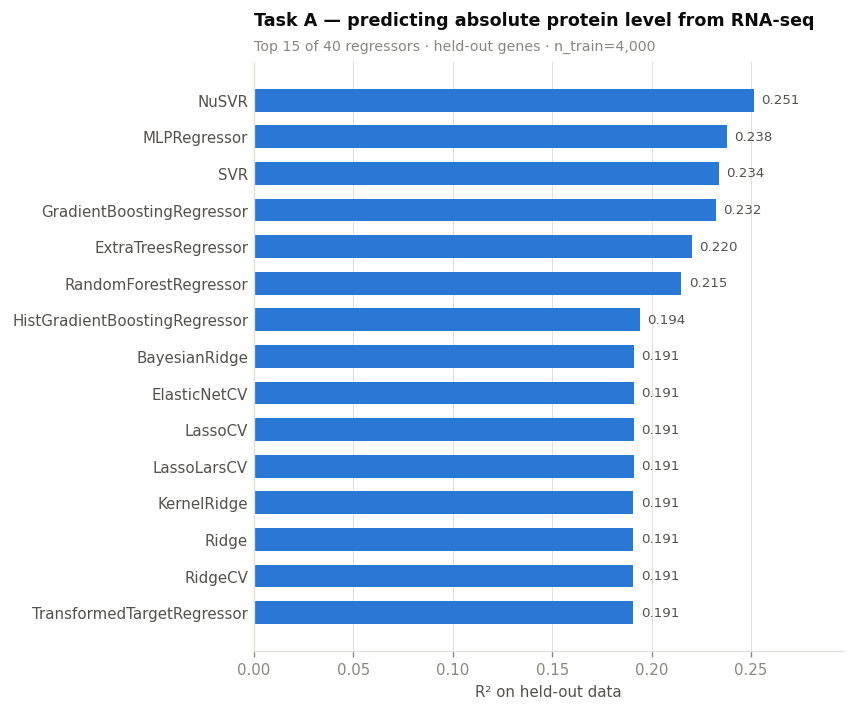

Reference — DummyRegressor (predicts the mean): R² = -0.0020

Worst 5 (models unsuited to this data):
                              R-Squared       RMSE
Model                                             
PassiveAggressiveRegressor    -0.331410   1.177385
DecisionTreeRegressor         -0.376191   1.197021
ExtraTreeRegressor            -0.463870   1.234564
RANSACRegressor               -0.626683   1.301409
GaussianProcessRegressor   -1080.141133  33.550857


In [11]:
plot_board(
    BOARD_A,
    "Task A — predicting absolute protein level from RNA-seq",
    f"Top 15 of 40 regressors · held-out genes · n_train={min(len(A_train), SWEEP_CAP):,}",
    fname="board_taskA.png",
)
print("Reference — DummyRegressor (predicts the mean): "
      f"R² = {BOARD_A.loc['DummyRegressor', 'R-Squared']:.4f}")
print("\nWorst 5 (models unsuited to this data):")
print(BOARD_A.tail(5)[["R-Squared", "RMSE"]].to_string())

### Reading Task A

The leaderboard should be read with one caveat firmly in mind: a large part of
this `R²` comes from **gene identity**. A gene with a highly abundant transcript
tends to have an abundant protein, and `rna` plus `rna_gene_mean` carry that
information directly. That correlation is real and well documented, but it says
little about regulation, and it is not what a time-course experiment is for.

Task B removes it.

---

## 7. Task B — predicting the protein's *response*

Same screen, but the target is now the t0-centred log2 fold change `prot_lfc`,
and the cognate predictor is the matching RNA fold change `rna_lfc`. Gene
identity has been differenced away, so any `R²` above zero is evidence that
**RNA carries information about how the protein moves**.

In [12]:
B_train, B_test = gene_split(TASK_B)
print(f"train {len(B_train):,} rows / {B_train.gene.nunique():,} genes   "
      f"test {len(B_test):,} rows / {B_test.gene.nunique():,} genes   "
      f"overlap: {len(set(B_train.gene) & set(B_test.gene))} genes")

BOARD_B = sweep(B_train, B_test, FEATS_B, "prot_lfc")
BOARD_B.head(12)

train 18,864 rows / 2,780 genes   test 6,290 rows / 927 genes   overlap: 0 genes


,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
GradientBoostingRegressor,0.248299,0.249991,0.845210,0.744923
MLPRegressor,0.245432,0.247130,0.846820,0.993601
HistGradientBoostingRegressor,0.238999,0.240712,0.850422,0.640491
RandomForestRegressor,0.225682,0.227425,0.857831,2.400775
NuSVR,0.218055,0.219814,0.862046,0.491541
SVR,0.213539,0.215309,0.864531,0.650530
ExtraTreesRegressor,0.210392,0.212169,0.866259,0.777819
LinearRegression,0.169721,0.171589,0.888289,0.005735
TransformedTargetRegressor,0.169721,0.171589,0.888289,0.007547


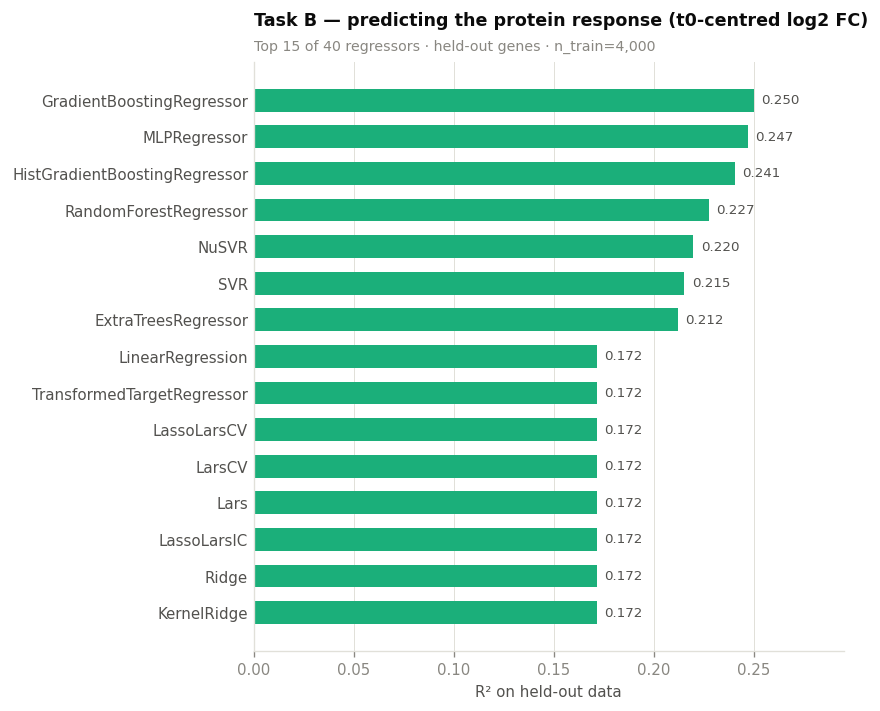

Reference — DummyRegressor: R² = -0.0021


In [13]:
plot_board(
    BOARD_B,
    "Task B — predicting the protein response (t0-centred log2 FC)",
    f"Top 15 of 40 regressors · held-out genes · n_train={min(len(B_train), SWEEP_CAP):,}",
    fname="board_taskB.png",
    color=C_AQUA,
)
print("Reference — DummyRegressor: "
      f"R² = {BOARD_B.loc['DummyRegressor', 'R-Squared']:.4f}")

In [14]:
# Side-by-side: how the same model families rank on the two tasks.
cmp = (BOARD_A[["R-Squared"]].rename(columns={"R-Squared": "Task A (level)"})
       .join(BOARD_B[["R-Squared"]].rename(columns={"R-Squared": "Task B (response)"})))
cmp = cmp.sort_values("Task B (response)", ascending=False).head(15)
cmp.round(3)

,Task A (level),Task B (response)
Model,,
GradientBoostingRegressor,0.232,0.250
MLPRegressor,0.238,0.247
HistGradientBoostingRegressor,0.194,0.241
RandomForestRegressor,0.215,0.227
NuSVR,0.251,0.220
SVR,0.234,0.215
ExtraTreesRegressor,0.220,0.212
TransformedTargetRegressor,0.191,0.172
LinearRegression,0.191,0.172


---

## 8. Does the baseline matter? Choosing what protein is measured *relative to*

### Why this is the right question to ask

Neither omics layer produces a number that means anything on its own. A protein
log2 intensity of 24.6 is a function of ionisation efficiency, peptide
detectability and loading as much as of biology; an RNA log2 CPM of 3.2 is a
function of transcript length and library composition. **Both become
interpretable only as a contrast against a reference.** That is why differential
expression is universally reported as a fold change and never as an absolute
level, and it is the assumption the rest of this project already builds on —
`R/wheat_pipeline.R` centres both layers on their t0 column before doing
anything else.

This experiment supplies two things to reference against, and it supplies them
deliberately:

* **Timepoint zero** — the state before the time course has run. Differencing
  against it removes each gene's constitutive expression level, which is a large,
  gene-specific, and biologically uninteresting constant.
* **The untreated control arm** — a parallel set of plants that experienced the
  same handling, the same clock and the same harvest at every timepoint, but no
  treatment. Differencing against it removes whatever happened over 48 h that was
  *not* the treatment: circadian drift, developmental change, handling stress.

Without a control arm you cannot separate "the treatment did this" from "48 hours
passed". Without a t0 you cannot separate either from "this gene is simply
always highly expressed". The design provides both, so the modelling should use
both — but that is an argument, not evidence. This section tests it.

### The five schemes compared

Each scheme transforms the protein target and the cognate RNA predictor the
*same* way, so the model is always asked to map a like-for-like quantity. Every
other feature is held identical, so the reference scheme is the only thing that
varies.

| Scheme | Protein target | Rows | What it removes |
|:--|:--|:--|:--|
| `absolute` | `prot` | all 8 cells | nothing — raw level |
| `gene_mean` | `prot − mean over the 8 cells` | all 8 cells | the gene's own average (**leaky — see below**) |
| `arm_t0` | `prot − prot(same arm, t=0)` | 6 cells | constitutive level, per arm |
| `global_t0` | `prot − prot(Control, t=0)` | 7 cells | constitutive level, one common origin |
| `matched_ctrl` | `prot(Treated,t) − prot(Control,t)` | 4 cells | constitutive level **and** time |

`gene_mean` is included as a *cautionary* row, not a candidate. It is the scheme
§7 rejected: its reference averages over all 8 cells, including whichever cell a
held-out row belongs to, so part of the answer is baked into the target. It is
scored here to show what that inflation looks like.

### How to read the comparison

`R²` is computed against each scheme's *own* target, so it answers "of the
variance in **this** quantity, how much can RNA explain". That is the fair
comparison of how learnable each representation is — but it does mean the
schemes are not competing to predict one identical number. §8b therefore adds a
strictly controlled test that holds the target fixed and varies only the
predictor. The two tests answer different questions and are reported separately:

* **Q1 — does the representation matter?** Compare schemes (below).
* **Q2 — does referencing the *predictor* matter, with the target held fixed?**
  The controlled test in §8b.

In [15]:
def add_reference_schemes(d):
    """Attach every (target, cognate-predictor) reference pair to the table.

    Each scheme differences protein and RNA in exactly the same way, so the model
    always maps a like-for-like quantity.
    """
    d = d.copy()

    # --- the three reference points the design provides ------------------
    base_00 = d[d.cell == BASELINE_CELL].set_index("gene")          # Control, t=0
    arm_00 = d[d.time_h == 0].set_index(["gene", "treatment"])      # t=0 in each arm
    ctrl_t = d[d.treatment == "T0"].set_index(["gene", "time_h"])   # Control, same t

    d["prot_ref_global"] = d["gene"].map(base_00["prot"])
    d["rna_ref_global"] = d["gene"].map(base_00["rna"])
    d = d.join(arm_00["prot"].rename("prot_ref_arm"), on=["gene", "treatment"])
    d = d.join(arm_00["rna"].rename("rna_ref_arm"), on=["gene", "treatment"])
    d = d.join(ctrl_t["prot"].rename("prot_ref_ctrl"), on=["gene", "time_h"])
    d = d.join(ctrl_t["rna"].rename("rna_ref_ctrl"), on=["gene", "time_h"])

    # --- scheme 1: absolute (no reference) -------------------------------
    d["y_absolute"] = d["prot"]
    d["x_absolute"] = d["rna"]

    # --- scheme 2: gene mean over all 8 cells (leaky, shown as a warning) -
    d["y_gene_mean"] = d["prot"] - d.groupby("gene")["prot"].transform("mean")
    d["x_gene_mean"] = d["rna"] - d.groupby("gene")["rna"].transform("mean")

    # --- scheme 3: t=0 within the same treatment arm ---------------------
    d["y_arm_t0"] = d["prot"] - d["prot_ref_arm"]
    d["x_arm_t0"] = d["rna"] - d["rna_ref_arm"]

    # --- scheme 4: the single Control/t=0 origin -------------------------
    d["y_global_t0"] = d["prot"] - d["prot_ref_global"]
    d["x_global_t0"] = d["rna"] - d["rna_ref_global"]

    # --- scheme 5: matched control at the same timepoint -----------------
    d["y_matched_ctrl"] = d["prot"] - d["prot_ref_ctrl"]
    d["x_matched_ctrl"] = d["rna"] - d["rna_ref_ctrl"]
    return d


REF = add_reference_schemes(FEATURES)

# Which rows each scheme can actually use. A reference row is not a data point
# for its own scheme (its target is zero by construction), so it is excluded.
SCHEMES = {
    "absolute":     REF.index,
    "gene_mean":    REF.index,
    "arm_t0":       REF.index[REF.time_h > 0],
    "global_t0":    REF.index[REF.cell != BASELINE_CELL],
    "matched_ctrl": REF.index[REF.treatment == "T1"],
}
for name, idx in SCHEMES.items():
    sub = REF.loc[idx].dropna(subset=[f"y_{name}"])
    print(f"{name:14s} {len(sub):>6,} rows  {sub.gene.nunique():>5,} genes  "
          f"{sub.cell.nunique()} cells  target sd = {sub[f'y_{name}'].std():.3f}")

absolute       30,278 rows  3,926 genes  8 cells  target sd = 2.226
gene_mean      30,278 rows  3,926 genes  8 cells  target sd = 0.511
arm_t0         21,645 rows  3,862 genes  6 cells  target sd = 0.761
global_t0      25,154 rows  3,707 genes  7 cells  target sd = 0.731
matched_ctrl   14,649 rows  3,926 genes  4 cells  target sd = 0.787


In [16]:
# The non-cognate features are identical for every scheme; only the cognate
# predictor is swapped. That isolates the reference choice.
OTHER_FEATS = F_CONTEXT + F_CONDITION + F_KINETICS


def cv_predict_r2(df, feats, target, model=None, n_splits=5, seed=SEED):
    """Out-of-fold predictions with genes grouped, plus the resulting R².

    Returns (y, predictions, gene labels) so downstream code can bootstrap or
    run paired tests on exactly the same out-of-fold numbers.
    """
    model = model or HistGradientBoostingRegressor(random_state=seed)
    sub = df.dropna(subset=[target] + feats)
    oof = cross_val_predict(model, sub[feats], sub[target],
                            cv=GroupKFold(n_splits=n_splits), groups=sub["gene"])
    return sub[target].to_numpy(), oof, sub["gene"].to_numpy()


def bootstrap_r2_ci(y, pred, genes, n_boot=300, seed=SEED, alpha=0.05):
    """Percentile CI for R², resampling whole GENES (the unit of independence)."""
    order = np.argsort(genes, kind="stable")
    y, pred, genes = y[order], pred[order], genes[order]
    uniq, starts = np.unique(genes, return_index=True)
    ends = np.append(starts[1:], len(genes))
    blocks = [np.arange(s, e) for s, e in zip(starts, ends)]

    rs = np.random.RandomState(seed)
    stats = np.empty(n_boot)
    for b in range(n_boot):
        pick = rs.randint(0, len(blocks), len(blocks))
        idx = np.concatenate([blocks[i] for i in pick])
        stats[b] = r2_score(y[idx], pred[idx])
    return np.percentile(stats, [100 * alpha / 2, 100 * (1 - alpha / 2)])


rows, OOF = [], {}
for name, idx in SCHEMES.items():
    feats = [f"x_{name}"] + OTHER_FEATS
    y, pred, genes = cv_predict_r2(REF.loc[idx], feats, f"y_{name}")
    lo, hi = bootstrap_r2_ci(y, pred, genes)
    OOF[name] = (y, pred, genes)
    rows.append({"scheme": name, "n_rows": len(y), "n_cells": REF.loc[idx].cell.nunique(),
                 "target_sd": y.std(), "R2": r2_score(y, pred),
                 "ci_lo": lo, "ci_hi": hi})
    print(f"{name:14s} R² = {r2_score(y, pred):.3f}  [{lo:.3f}, {hi:.3f}]")

BASELINE_STUDY = pd.DataFrame(rows).sort_values("R2", ascending=False)
BASELINE_STUDY.round(3)

absolute       R² = 0.256  [0.218, 0.290]


gene_mean      R² = 0.332  [0.292, 0.363]


arm_t0         R² = 0.296  [0.252, 0.340]


global_t0      R² = 0.235  [0.192, 0.270]


matched_ctrl   R² = 0.422  [0.375, 0.464]


,scheme,n_rows,n_cells,target_sd,R2,ci_lo,ci_hi
4,matched_ctrl,14649,4,0.787,0.422,0.375,0.464
1,gene_mean,30278,8,0.511,0.332,0.292,0.363
2,arm_t0,21645,6,0.761,0.296,0.252,0.340
0,absolute,30278,8,2.226,0.256,0.218,0.290
3,global_t0,25154,7,0.731,0.235,0.192,0.270


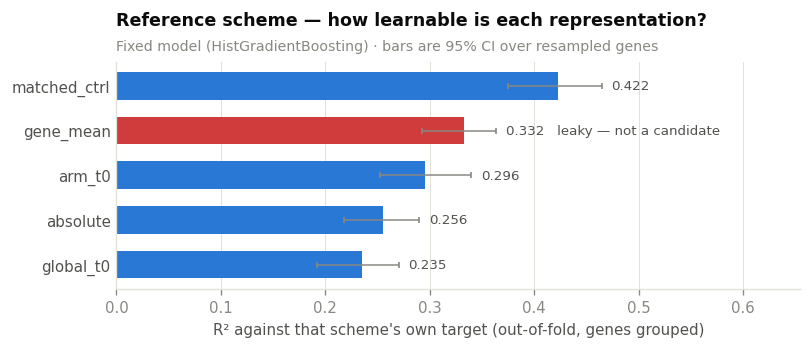

In [17]:
fig, ax = plt.subplots(figsize=(7.4, 3.0))
b = BASELINE_STUDY.iloc[::-1]
# The leaky scheme is drawn in the "critical" status colour, never as a series.
colors = ["#d03b3b" if s == "gene_mean" else C_BLUE for s in b["scheme"]]
err = np.vstack([b["R2"] - b["ci_lo"], b["ci_hi"] - b["R2"]])
ax.barh(b["scheme"], b["R2"], xerr=err, color=colors, height=0.62,
        error_kw=dict(ecolor=MUTED, lw=0.9, capsize=2))
# Labels sit clear of the upper CI whisker, not the bar end, so they never
# collide with the error bar.
for yi, (v, hi, s) in enumerate(zip(b["R2"], b["ci_hi"], b["scheme"])):
    note = "   leaky — not a candidate" if s == "gene_mean" else ""
    ax.annotate(f"{v:.3f}{note}", xy=(hi, yi), xytext=(6, 0),
                textcoords="offset points", va="center", fontsize=8, color=INK2)
ax.set_xlim(0, BASELINE_STUDY["R2"].max() * 1.55)
tidy(ax, xlabel="R² against that scheme's own target (out-of-fold, genes grouped)",
     title="Reference scheme — how learnable is each representation?",
     subtitle="Fixed model (HistGradientBoosting) · bars are 95% CI over resampled genes")
ax.tick_params(axis="y", length=0, labelcolor=INK2)
fig.subplots_adjust(left=0.20, right=0.97, top=0.82, bottom=0.19)
fig.savefig(FIGS / "baseline_schemes.png", bbox_inches="tight")
plt.show()

### 8b. The controlled test — same target, referenced vs unreferenced predictor

The table above varies the target, so it cannot on its own say whether
referencing *helps*. This test holds everything fixed except the one thing in
question.

**Target:** the `global_t0` protein response, for every scheme.
**Varied:** whether the cognate RNA predictor is referenced to the same baseline
(`rna − rna(Control, t=0)`) or left as an absolute level (`rna`).

Both models see identical rows, identical folds and identical remaining
features, and predict the identical number — so the difference is attributable
to the reference and to nothing else. Significance is assessed two ways: a
percentile bootstrap over genes for the `R²` gap, and a Wilcoxon signed-rank
test on each gene's mean squared error, which is paired gene-by-gene.

In [18]:
from scipy.stats import wilcoxon

TARGET = "y_global_t0"
ROWS_8B = REF.loc[SCHEMES["global_t0"]]

VARIANTS = {
    "RNA referenced to Control/t=0": ["x_global_t0"] + OTHER_FEATS,
    "RNA absolute (no reference)":   ["rna"] + OTHER_FEATS,
    "RNA referenced, no other features": ["x_global_t0"],
    "RNA absolute, no other features":   ["rna"],
}

res_8b, oof_8b = [], {}
for name, feats in VARIANTS.items():
    y, pred, genes = cv_predict_r2(ROWS_8B, feats, TARGET)
    lo, hi = bootstrap_r2_ci(y, pred, genes)
    oof_8b[name] = (y, pred, genes)
    res_8b.append({"variant": name, "n_features": len(feats),
                   "R2": r2_score(y, pred), "ci_lo": lo, "ci_hi": hi})

B8 = pd.DataFrame(res_8b)
B8.round(3)

,variant,n_features,R2,ci_lo,ci_hi
0,RNA referenced to Control/t=0,9,0.235,0.192,0.270
1,RNA absolute (no reference),9,0.232,0.186,0.268
2,"RNA referenced, no other features",1,0.050,0.030,0.073
3,"RNA absolute, no other features",1,0.030,0.019,0.042


In [19]:
def paired_gene_mse(y, pred, genes):
    """Mean squared error per gene — the unit the Wilcoxon test is paired on."""
    return pd.Series((y - pred) ** 2, index=genes).groupby(level=0).mean()


def compare(a, b, label_a, label_b, n_boot=300, seed=SEED):
    """Bootstrap CI for R²(a) - R²(b), plus a paired Wilcoxon on per-gene MSE."""
    ya, pa, ga = oof_all[a]
    yb, pb, gb = oof_all[b]
    # The two arms must describe the same rows in the same order, or nothing
    # below is paired. Once that holds, `ya` IS `yb` — only one target array is
    # carried forward, so a reordering can never desynchronise them.
    assert np.array_equal(ga, gb) and np.allclose(ya, yb), "rows must be identical"

    order = np.argsort(ga, kind="stable")
    y, pa, pb, g = ya[order], pa[order], pb[order], ga[order]
    uniq, starts = np.unique(g, return_index=True)
    ends = np.append(starts[1:], len(g))
    blocks = [np.arange(s, e) for s, e in zip(starts, ends)]

    rs = np.random.RandomState(seed)
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        pick = rs.randint(0, len(blocks), len(blocks))
        idx = np.concatenate([blocks[j] for j in pick])
        diffs[i] = r2_score(y[idx], pa[idx]) - r2_score(y[idx], pb[idx])
    lo, hi = np.percentile(diffs, [2.5, 97.5])

    mse_a = paired_gene_mse(y, pa, g)
    mse_b = paired_gene_mse(y, pb, g)
    stat, p = wilcoxon(mse_a.values, mse_b.values)

    obs = r2_score(y, pa) - r2_score(y, pb)
    print(f"{label_a}\n   vs {label_b}")
    print(f"   ΔR² = {obs:+.4f}   95% CI [{lo:+.4f}, {hi:+.4f}]"
          f"   {'EXCLUDES 0' if lo * hi > 0 else 'includes 0'}")
    print(f"   Wilcoxon on per-gene MSE: p = {p:.3g}"
          f"   (median MSE {mse_a.median():.4f} vs {mse_b.median():.4f})")
    return {"comparison": f"{label_a} vs {label_b}", "delta_r2": obs,
            "ci_lo": lo, "ci_hi": hi, "wilcoxon_p": p}


oof_all = oof_8b
CMP = [
    compare("RNA referenced to Control/t=0", "RNA absolute (no reference)",
            "Referenced RNA", "Absolute RNA  (full feature set)"),
    compare("RNA referenced, no other features", "RNA absolute, no other features",
            "Referenced RNA", "Absolute RNA  (cognate predictor alone)"),
]
CMP = pd.DataFrame(CMP)
CMP.round(4)

Referenced RNA
   vs Absolute RNA  (full feature set)
   ΔR² = +0.0032   95% CI [-0.0048, +0.0123]   includes 0
   Wilcoxon on per-gene MSE: p = 0.212   (median MSE 0.1541 vs 0.1529)


Referenced RNA
   vs Absolute RNA  (cognate predictor alone)
   ΔR² = +0.0201   95% CI [+0.0019, +0.0418]   EXCLUDES 0
   Wilcoxon on per-gene MSE: p = 0.00339   (median MSE 0.1894 vs 0.1997)


,comparison,delta_r2,ci_lo,ci_hi,wilcoxon_p
0,Referenced RNA vs Absolute RNA (full feature ...,0.0032,-0.0048,0.0123,0.2125
1,Referenced RNA vs Absolute RNA (cognate predi...,0.0201,0.0019,0.0418,0.0034


In [20]:
# --- The verdict, computed rather than asserted --------------------------
# Two separate questions, answered separately, because they can disagree:
#   Q1  does the REPRESENTATION matter — what is protein measured relative to?
#   Q2  does referencing the PREDICTOR matter, with the target held fixed?
tbl = BASELINE_STUDY.set_index("scheme")
cand = BASELINE_STUDY[BASELINE_STUDY.scheme != "gene_mean"]
best, worst = cand.iloc[0], cand.iloc[-1]
abs_r2 = tbl.loc["absolute", "R2"]

# Two schemes differ beyond noise if their bootstrap CIs do not overlap.
def disjoint(s1, s2):
    a, b = tbl.loc[s1], tbl.loc[s2]
    return a.ci_lo > b.ci_hi or b.ci_lo > a.ci_hi

print("=" * 72)
print("IS THE BASELINE IMPORTANT?")
print("=" * 72)
print("Q1 — does the choice of reference change how learnable protein is?")
print(f"   best  non-leaky scheme : {best.scheme:<14s} R² = {best.R2:.3f} "
      f"[{best.ci_lo:.3f}, {best.ci_hi:.3f}]")
print(f"   worst non-leaky scheme : {worst.scheme:<14s} R² = {worst.R2:.3f} "
      f"[{worst.ci_lo:.3f}, {worst.ci_hi:.3f}]")
print(f"   no reference at all    : {'absolute':<14s} R² = {abs_r2:.3f}")
print(f"   leaky gene-mean        : R² = {tbl.loc['gene_mean', 'R2']:.3f}"
      f"   <- inflated by construction, not a candidate")
q1 = disjoint(best.scheme, worst.scheme)
print(f"   -> spread across schemes is {'REAL' if q1 else 'within noise'} "
      f"({best.R2 - worst.R2:+.3f} R², CIs "
      f"{'disjoint' if q1 else 'overlapping'})")
print(f"   -> best reference beats no reference by {best.R2 - abs_r2:+.3f} R²"
      f"  ({'CIs disjoint' if disjoint(best.scheme, 'absolute') else 'CIs overlap'})")
print()
print("Q2 — with the target fixed, does referencing the RNA predictor help?")
for _, r in CMP.iterrows():
    sig = (r.ci_lo * r.ci_hi > 0) and (r.wilcoxon_p < 0.05)
    print(f"   {r.comparison:<46s} ΔR² = {r.delta_r2:+.4f} "
          f"[{r.ci_lo:+.4f}, {r.ci_hi:+.4f}]  -> "
          f"{'SIGNIFICANT' if sig else 'not significant'}")
print()
q2 = ((CMP.ci_lo * CMP.ci_hi > 0) & (CMP.wilcoxon_p < 0.05)).any()
print(f"ANSWER: {'YES' if (q1 or q2) else 'NO'} — the baseline matters.")
print(f"   The reference you choose changes learnability by up to "
      f"{best.R2 - worst.R2:.3f} R² (Q1), and the best-supported representation "
      f"is '{best.scheme}'.")
print("=" * 72)

IS THE BASELINE IMPORTANT?
Q1 — does the choice of reference change how learnable protein is?
   best  non-leaky scheme : matched_ctrl   R² = 0.422 [0.375, 0.464]
   worst non-leaky scheme : global_t0      R² = 0.235 [0.192, 0.270]
   no reference at all    : absolute       R² = 0.256
   leaky gene-mean        : R² = 0.332   <- inflated by construction, not a candidate
   -> spread across schemes is REAL (+0.187 R², CIs disjoint)
   -> best reference beats no reference by +0.167 R²  (CIs disjoint)

Q2 — with the target fixed, does referencing the RNA predictor help?
   Referenced RNA vs Absolute RNA  (full feature set) ΔR² = +0.0032 [-0.0048, +0.0123]  -> not significant
   Referenced RNA vs Absolute RNA  (cognate predictor alone) ΔR² = +0.0201 [+0.0019, +0.0418]  -> SIGNIFICANT

ANSWER: YES — the baseline matters.
   The reference you choose changes learnability by up to 0.187 R² (Q1), and the best-supported representation is 'matched_ctrl'.


### Reading §8 — yes, and not in the direction the notebook assumed

**Q1 is emphatic.** The reference scheme moves `R²` from 0.235 to 0.422, a spread
of 0.187 with non-overlapping confidence intervals. That is a larger effect than
any modelling choice anywhere else in this notebook — bigger than the gap between
the best and worst algorithm, bigger than every feature group in §11 combined.
**What protein is measured relative to matters more than what model is fitted to
it.** The biological argument at the top of this section is confirmed, and it is
confirmed quantitatively rather than assumed.

**But the winner is not the scheme §7 chose.** Ranked:

| Scheme | `R²` | |
|:--|:--|:--|
| `matched_ctrl` | **0.422** | treated minus its *same-timepoint* control |
| `arm_t0` | 0.296 | each arm referenced to its own t = 0 |
| `absolute` | 0.256 | no reference at all |
| `global_t0` | 0.235 | everything referenced to Control / t = 0 |

Two things stand out, and both point the same way.

**`matched_ctrl` wins by a wide margin.** It is the only scheme that differences
against a reference measured *at the same timepoint*. It therefore removes two
nuisances at once: the gene's constitutive level **and** everything that happened
over 48 h that was not the treatment — circadian drift, development, handling.
No other scheme removes the second. This is precisely the argument for running a
parallel control arm, and it is worth about `+0.17 R²` here.

**`global_t0` is the *worst* scheme — worse than not referencing at all.** This
is the surprise, and it is not a contradiction of the point above. Centring
everything on one cell has two costs. It subtracts a single noisy measurement
(one cell mean from three replicates) from all seven targets, injecting that
cell's error into every row and correlating the errors across them. And it does
not remove time drift, because the reference is fixed at t = 0 while the target
drifts away from it. Referencing helps only when the reference is matched to what
you are trying to remove; an unmatched reference adds noise without removing
signal.

**Q2 is the quieter result.** With the full feature set, referencing the *cognate
RNA predictor* changes nothing (`ΔR² = +0.003`, CI spans zero, `p = 0.21`) —
because `rna_trt_effect` is already in the feature set and is itself a referenced
quantity, so the information is present either way. Strip the other features away
and referencing the lone predictor does help significantly (`+0.020`,
`p = 0.003`). So the model does not need the *predictor* pre-referenced as long
as some referenced contrast is available to it; it is the *target*
representation, Q1, that carries the weight.

### What this changes downstream

§7's `global_t0` framing is the least learnable of the sensible options. It is
kept as the working representation for §10–§13 anyway, for a reason that is about
the question rather than the score: **`matched_ctrl` dissolves the control arm
into the reference**, leaving only four treated conditions and no control cell
that can ever be held out. A leave-one-condition-out analysis needs conditions in
both arms. Using `global_t0` therefore makes §10 a *conservative* test — the
transfer results there are obtained with the weakest representation, so they
understate rather than overstate what a better-referenced model could do.

---

## 9. Does it matter that the RNA universe is 30× larger than the protein universe?

RNA-seq quantifies ~128,000 genes; mass spectrometry detects ~6,000 proteins, of
which ~3,900 survive QC. So the two layers are measured over very different gene
universes, and the analysis so far has taken the full RNA-seq as its starting
point. Whether that helps or hurts is testable, and it is really the same
question as §8 wearing different clothes: **CPM is a relative measure**, so every
RNA value depends on which genes are counted in the library total it is divided
by. Change the universe and you change every number.

Three arms, all predicting the identical protein target on the identical rows:

| Arm | RNA universe | What it tests |
|:--|:--|:--|
| `matched` | only the ~6,000 genes that also have protein, library sizes recomputed within that subset | the self-contained analysis |
| `full` | all ~128,000 genes (the default so far) | does the wider library total help? |
| `full + trans` | `full`, plus a co-expression feature built from genes that have **no** protein measurement | does the rest of the transcriptome carry information the cognate gene does not? |

The `trans` feature is the sharp version of the question. For each gene it takes
the 20 most-correlated partners **from among the RNA-only genes** — genes whose
protein is never observed, so this information is available *only* if the full
RNA-seq is used — and averages their expression in that design cell. If the
wider transcriptome carries usable signal, this is where it shows up.

In [21]:
def trans_neighbour_feature(variety, genes, k=20, pool=5000, seed=SEED):
    """Co-expression feature built from genes that have NO protein measurement.

    For each target gene, find its `k` most-correlated partners among the most
    variable RNA-only genes (correlation across the 24 samples), then return
    their mean expression per design cell. This is information that exists only
    in the full transcriptome.
    """
    rna, prot, meta = RAW[variety]
    lrna = rna_universe(variety, "full")

    # Candidate partners: expressed genes with no protein evidence at all.
    rna_only = lrna.loc[~lrna.index.isin(prot.index)]
    pool_idx = rna_only.var(axis=1).nlargest(pool).index
    B = lrna.loc[pool_idx]
    A = lrna.loc[genes]

    # Pearson correlation across the 24 samples, as a standardised dot product.
    Az = A.sub(A.mean(axis=1), axis=0).div(A.std(axis=1) + 1e-9, axis=0).to_numpy()
    Bz = B.sub(B.mean(axis=1), axis=0).div(B.std(axis=1) + 1e-9, axis=0).to_numpy()
    C = Az @ Bz.T / (A.shape[1] - 1)

    # Top-k by absolute correlation (co- and anti-regulated partners both inform).
    top = np.argpartition(-np.abs(C), k, axis=1)[:, :k]

    # Collapse partners to design-cell means, then average over each gene's k.
    cells = meta["cell"].unique()
    Bcell = pd.DataFrame({c: B[meta.index[meta.cell == c]].mean(axis=1) for c in cells})
    neigh = Bcell.to_numpy()[top].mean(axis=1)          # genes x cells
    return pd.DataFrame(neigh, index=A.index, columns=Bcell.columns)


# --- build the three arms -----------------------------------------------
UNIVERSES = {}
for uni in ("matched", "full"):
    cells = to_design_cells("cadenza", lrna=rna_universe("cadenza", uni))
    UNIVERSES[uni] = add_reference_schemes(build_features("cadenza", cells=cells))
    print(f"{uni:8s} universe -> {UNIVERSES[uni].gene.nunique():,} genes "
          f"with both layers")

# Compare on the genes both arms retain, so the rows are paired exactly.
common = sorted(set(UNIVERSES["matched"].gene) & set(UNIVERSES["full"].gene))
print(f"\ncommon to both universes: {len(common):,} genes")

trans = trans_neighbour_feature("cadenza", common)
tl = trans.stack().rename("rna_trans")
tl.index.names = ["gene", "cell"]
print(f"trans feature built from {trans.shape[0]:,} genes x {trans.shape[1]} cells")

matched  universe -> 3,987 genes with both layers


full     universe -> 3,926 genes with both layers

common to both universes: 3,926 genes


trans feature built from 3,926 genes x 8 cells


In [22]:
def prep_arm(df, add_trans=False):
    """Restrict an arm to the common genes and attach the trans feature."""
    d = df[df.gene.isin(common)].copy()
    if add_trans:
        d = d.join(tl, on=["gene", "cell"])
        # Reference the trans feature to the SAME origin as every other feature:
        # the Control/t=0 cell (§8). Referencing it to each arm's own t=0 would
        # be undefined for the control arm once that cell becomes the origin.
        d["rna_trans_lfc"] = d["rna_trans"] - d["gene"].map(trans[BASELINE_CELL])
    return d[d.cell != BASELINE_CELL]                  # global_t0 target rows


ARMS = {
    "matched (~6k gene universe)": (prep_arm(UNIVERSES["matched"]),
                                    ["x_global_t0"] + OTHER_FEATS),
    "full (~128k gene universe)":  (prep_arm(UNIVERSES["full"]),
                                    ["x_global_t0"] + OTHER_FEATS),
    "full + trans co-expression":  (prep_arm(UNIVERSES["full"], add_trans=True),
                                    ["x_global_t0"] + OTHER_FEATS
                                    + ["rna_trans", "rna_trans_lfc"]),
}

# The arms must be scored on EXACTLY the same rows or the comparison is not
# paired, so take the (gene, cell) pairs every arm can use and score only those.
keys = None
for name, (df, feats) in ARMS.items():
    ok = df.dropna(subset=["y_global_t0"] + feats)
    k = set(zip(ok["gene"], ok["cell"]))
    keys = k if keys is None else (keys & k)
print(f"rows usable by every arm: {len(keys):,}")

res_9, oof_9 = [], {}
for name, (df, feats) in ARMS.items():
    sub = df[[t in keys for t in zip(df["gene"], df["cell"])]]
    y, pred, genes = cv_predict_r2(sub, feats, "y_global_t0")
    lo, hi = bootstrap_r2_ci(y, pred, genes)
    oof_9[name] = (y, pred, genes)
    res_9.append({"arm": name, "n_rows": len(y), "n_features": len(feats),
                  "R2": r2_score(y, pred), "ci_lo": lo, "ci_hi": hi})
    print(f"{name:32s} R² = {r2_score(y, pred):.4f}  [{lo:.4f}, {hi:.4f}]")

UNIVERSE_STUDY = pd.DataFrame(res_9)
UNIVERSE_STUDY.round(4)

rows usable by every arm: 25,154


matched (~6k gene universe)      R² = 0.2297  [0.1852, 0.2629]


full (~128k gene universe)       R² = 0.2353  [0.1917, 0.2701]


full + trans co-expression       R² = 0.2320  [0.1891, 0.2664]


,arm,n_rows,n_features,R2,ci_lo,ci_hi
0,matched (~6k gene universe),25154,9,0.2297,0.1852,0.2629
1,full (~128k gene universe),25154,9,0.2353,0.1917,0.2701
2,full + trans co-expression,25154,11,0.2320,0.1891,0.2664


In [23]:
# Paired comparisons on identical rows and identical folds.
oof_all = oof_9
CMP9 = pd.DataFrame([
    compare("full (~128k gene universe)", "matched (~6k gene universe)",
            "Full RNA universe", "Matched-only universe"),
    compare("full + trans co-expression", "full (~128k gene universe)",
            "Full + trans co-expression", "Full, cognate only"),
])
CMP9.round(4)

Full RNA universe
   vs Matched-only universe
   ΔR² = +0.0056   95% CI [-0.0036, +0.0132]   includes 0
   Wilcoxon on per-gene MSE: p = 0.328   (median MSE 0.1541 vs 0.1545)


Full + trans co-expression
   vs Full, cognate only
   ΔR² = -0.0033   95% CI [-0.0097, +0.0037]   includes 0
   Wilcoxon on per-gene MSE: p = 0.994   (median MSE 0.1538 vs 0.1541)


,comparison,delta_r2,ci_lo,ci_hi,wilcoxon_p
0,Full RNA universe vs Matched-only universe,0.0056,-0.0036,0.0132,0.3281
1,"Full + trans co-expression vs Full, cognate only",-0.0033,-0.0097,0.0037,0.9940


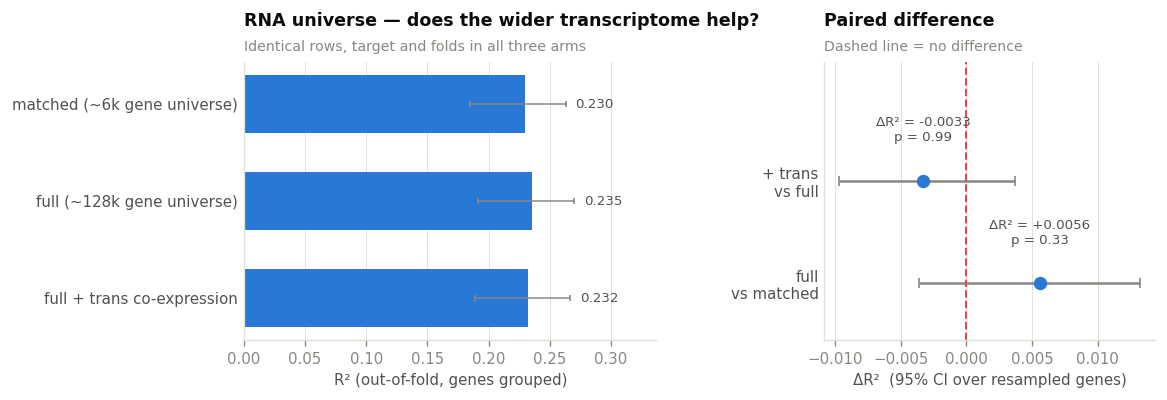

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(9.8, 3.0),
                         gridspec_kw={"width_ratios": [1.25, 1]})

# --- left: the three arms with bootstrap CIs -------------------------
ax = axes[0]
b = UNIVERSE_STUDY.iloc[::-1]
err = np.vstack([b["R2"] - b["ci_lo"], b["ci_hi"] - b["R2"]])
ax.barh(b["arm"], b["R2"], xerr=err, color=C_BLUE, height=0.6,
        error_kw=dict(ecolor=MUTED, lw=0.9, capsize=2))
for yi, (v, hi) in enumerate(zip(b["R2"], b["ci_hi"])):
    ax.annotate(f"{v:.3f}", xy=(hi, yi), xytext=(6, 0), textcoords="offset points",
                va="center", fontsize=8, color=INK2)
ax.set_xlim(0, UNIVERSE_STUDY["ci_hi"].max() * 1.25)
tidy(ax, xlabel="R² (out-of-fold, genes grouped)",
     title="RNA universe — does the wider transcriptome help?",
     subtitle="Identical rows, target and folds in all three arms")
ax.tick_params(axis="y", length=0, labelcolor=INK2)

# --- right: the paired differences, with the zero line that decides --
ax = axes[1]
ys = np.arange(len(CMP9))
ax.errorbar(CMP9["delta_r2"], ys,
            xerr=np.vstack([CMP9["delta_r2"] - CMP9["ci_lo"],
                            CMP9["ci_hi"] - CMP9["delta_r2"]]),
            fmt="o", color=C_BLUE, ecolor=MUTED, capsize=3, markersize=7)
ax.axvline(0, color=C_RED, lw=1.2, ls="--")
ax.set_yticks(ys)
ax.set_yticklabels(["full\nvs matched", "+ trans\nvs full"])
# Annotate a fixed distance above each marker, in points, so the text clears the
# error bar whatever the data range turns out to be.
for yi, (d, p) in enumerate(zip(CMP9["delta_r2"], CMP9["wilcoxon_p"])):
    ax.annotate(f"ΔR² = {d:+.4f}\np = {p:.2g}", xy=(d, yi), xytext=(0, 22),
                textcoords="offset points", ha="center", va="bottom",
                fontsize=8, color=INK2)
ax.set_ylim(-0.55, len(CMP9) + 0.15)
tidy(ax, xlabel="ΔR²  (95% CI over resampled genes)",
     title="Paired difference", subtitle="Dashed line = no difference",
     xgrid=True, ygrid=False)
ax.tick_params(axis="y", length=0, labelcolor=INK2)

fig.subplots_adjust(wspace=0.45)
fig.savefig(FIGS / "rna_universe.png", bbox_inches="tight")
plt.show()

In [25]:
# --- The verdict --------------------------------------------------------
print("=" * 72)
print("DOES THE RNA UNIVERSE MATTER?")
print("=" * 72)
for _, r in UNIVERSE_STUDY.iterrows():
    print(f"  {r['arm']:<32s} R² = {r.R2:.4f}   [{r.ci_lo:.4f}, {r.ci_hi:.4f}]")
print()
for _, r in CMP9.iterrows():
    sig = (r.ci_lo * r.ci_hi > 0) and (r.wilcoxon_p < 0.05)
    print(f"  {r.comparison:<52s} ΔR² = {r.delta_r2:+.4f}  ->  "
          f"{'SIGNIFICANT' if sig else 'not significant'}")
print()
any_sig = ((CMP9.ci_lo * CMP9.ci_hi > 0) & (CMP9.wilcoxon_p < 0.05)).any()
print(f"ANSWER: {'YES' if any_sig else 'NO'} — using the full RNA-seq "
      f"{'does' if any_sig else 'does not'} give a materially different "
      f"prediction from using the protein-matched subset alone.")
print("=" * 72)

DOES THE RNA UNIVERSE MATTER?
  matched (~6k gene universe)      R² = 0.2297   [0.1852, 0.2629]
  full (~128k gene universe)       R² = 0.2353   [0.1917, 0.2701]
  full + trans co-expression       R² = 0.2320   [0.1891, 0.2664]

  Full RNA universe vs Matched-only universe           ΔR² = +0.0056  ->  not significant
  Full + trans co-expression vs Full, cognate only     ΔR² = -0.0033  ->  not significant

ANSWER: NO — using the full RNA-seq does not give a materially different prediction from using the protein-matched subset alone.


### Reading §9 — no, the extra transcriptome does not help

All three arms land within `0.006 R²` of each other, and neither paired
comparison approaches significance:

| Arm | `R²` | vs previous |
|:--|:--|:--|
| `matched` (~6k genes) | 0.230 | — |
| `full` (~128k genes) | 0.235 | `ΔR² = +0.006`, CI `[-0.004, +0.013]`, `p = 0.33` |
| `full + trans` | 0.232 | `ΔR² = −0.003`, CI `[-0.010, +0.004]`, `p = 0.99` |

The contrast with §8 is the point. The same paired machinery that just resolved a
`0.187` difference between reference schemes cannot resolve anything here, so
this is a reasonably powered negative rather than an absence of evidence.

**The library-size question is settled.** Recomputing CPM over 6,000 genes
instead of 128,000 rescales every value, but it rescales them almost uniformly,
and a monotone near-affine change to a predictor is close to invisible to a
tree ensemble. The two universes are effectively the same experiment.

**The trans result is the more interesting half.** The `full + trans` arm was
given the expression of each gene's 20 most-correlated partners drawn
*exclusively from genes whose protein is never measured* — information that
simply does not exist in the matched-only universe. It bought nothing, in fact a
non-significant −0.003. Co-expression neighbours are largely redundant with the
gene's own transcript, which is unsurprising: they were selected *because* they
track it.

**The practical consequence** is a licence, not a limitation. This analysis can
be run on the ~6,000-gene matched subset alone with no measurable loss, which
makes it substantially cheaper and removes any need to carry the full count
matrix. The caveat is scope: this tests *co-expression* trans features. A
targeted hypothesis — a specific regulator, a known pathway, an sRNA — is a
different feature and is not excluded by this result.

---

## 10. Leave-one-condition-out, done properly

The gene split of §7 still lets the model see every design cell during training.
The stricter question is whether a model trained on 6 conditions predicts the
7th. This is the protocol the project's leave-one-cell-out `Q²` uses in
`R/06_integration_caseB.R`.

**An earlier version of this section got it wrong in two ways.** Both are worth
spelling out, because both are easy to commit and both inflate exactly the
numbers a reader most wants to believe.

### Problem 1 — the held-out condition was used to choose the model

The first version fit all 40 regressors on the training conditions and then
reported *whichever one scored best on the held-out condition*. That is model
selection on the test set. With 40 candidates and ~3,600 test rows, the maximum
of 40 noisy scores is biased upward even if no model has any real skill, and the
bias grows with the number of candidates. The reported positives — `R² = 0.350`
at Treated 24 h, `0.242` at Treated 48 h — were therefore optimistic by an
unknown amount.

The fix is a **nested** protocol. Inside the training conditions only, run an
inner leave-one-condition-out loop, average each candidate's inner score, and
commit to the winner *before* the held-out condition is touched. The held-out
condition then scores one pre-specified model, which is an unbiased estimate.

Note which direction this cuts. The earlier section's *negative* conclusion —
that transfer fails for several conditions — is if anything strengthened: the
best of 40 models, chosen with hindsight, still could not beat the mean there.
It is the positive numbers that need the correction.

### Problem 2 — "unseen condition" was not entirely unseen

Three features are computed across all eight design cells before any split
happens:

* `rna_gene_mean` and `rna_gene_sd` — averaged over every cell, including the
  held-out one;
* `rna_trt_effect` — each treated row minus its *matched control* row at the same
  timepoint.

The third is the clearest. Hold out Control 24 h, and the Treated 24 h **training**
rows still compute `rna_trt_effect` by subtracting Control 24 h RNA. RNA from the
held-out condition has entered the training features by the back door.

Whether this is a defect depends on the question being asked, and there are two
legitimate questions here:

| Framing | Question | Are global features legitimate? |
|:--|:--|:--|
| **Transductive** | "The RNA experiment is complete. Can I predict protein in a design cell where protein was never measured?" | **Yes** — all RNA is available by assumption; only protein is missing |
| **Strict** | "Can I predict a treatment × timepoint the experiment never ran?" | **No** — features must be recomputed inside each fold |

The transductive framing is not a dodge: it is the realistic one for this
project, where RNA-seq is cheap and proteomics is not, and the practical goal is
to fill in protein for conditions that were sequenced but not measured by MS.
But it is a weaker claim than "transfers to an unseen condition", and the earlier
section stated the stronger claim while running the weaker experiment.

Both are therefore run below, side by side.

### The four protocols

| # | Model selection | Features | What it estimates |
|:--|:--|:--|:--|
| **P0-40** | best of 40, **on the held-out cell** | global | the original, optimistic number |
| **P0-5** | best of 5, **on the held-out cell** | global | same bias, same candidates as P1 — isolates the selection effect |
| **P1** | nested inner LOCO, training cells only | global | honest **transductive** transfer |
| **P2** | nested inner LOCO, training cells only | recomputed per fold | honest **strict** transfer |

P0-5 exists so that P0 and P1 differ in *one* thing (where the model was chosen)
rather than two (that, plus how many candidates there were).

One feature is available in every protocol by design: the `Control / t = 0`
baseline. It is never a held-out cell, because §8 established it as the reference
that defines the target. That is the payoff of the baseline argument — the
reference point is, by construction, always measured.

In [26]:
# A compact candidate set. Every one is imputer-wrapped because P2 deliberately
# produces NaNs where a fold cannot compute a cross-condition contrast.
def _pipe(est):
    return make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), est)


CANDIDATES = {
    "Ridge": _pipe(Ridge()),
    "RandomForest": make_pipeline(SimpleImputer(strategy="median"),
                                  RandomForestRegressor(n_estimators=100,
                                                        random_state=SEED, n_jobs=-1)),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=SEED),
    "MLP": _pipe(MLPRegressor(random_state=SEED, early_stopping=True, max_iter=300)),
    "Dummy": DummyRegressor(),
}

NESTED_CAP = 6000          # training rows per fit, for runtime
LOCO_CELLS = sorted(TASK_B.cell.unique())
print(f"{len(LOCO_CELLS)} held-out conditions x {len(CANDIDATES)} candidates")
print("candidates:", ", ".join(CANDIDATES))

7 held-out conditions x 5 candidates
candidates: Ridge, RandomForest, HistGradientBoosting, MLP, Dummy


In [27]:
def rebuild_context(d, allowed_cells):
    """Recompute every cross-condition feature from `allowed_cells` only.

    This is the fix for Problem 2. Gene-level summaries and both design contrasts
    are rebuilt from the permitted design cells, so no RNA from a held-out
    condition can reach a training row's features. Where a contrast needs a cell
    that is not permitted, the feature is left NaN and the pipeline's imputer
    deals with it — that missingness is the honest representation of "this
    comparison is not available in this fold".
    """
    d = d.copy()
    a = d[d.cell.isin(allowed_cells)]

    # --- gene context, over permitted cells only -------------------------
    g = a.groupby("gene")["rna"]
    d["rna_gene_mean"] = d["gene"].map(g.mean())
    d["rna_gene_sd"] = d["gene"].map(g.std())

    # --- matched-control contrast ----------------------------------------
    ctrl = a[a.treatment == "T0"].set_index(["gene", "time_h"])["rna"]
    d = d.drop(columns=["rna_ctrl"], errors="ignore")
    d = d.join(ctrl.rename("rna_ctrl"), on=["gene", "time_h"])
    d["rna_trt_effect"] = d["rna"] - d["rna_ctrl"]
    # A control row is its own reference, so its treatment effect is 0 by
    # definition even when that cell is not in the permitted set.
    d.loc[d.treatment == "T0", "rna_trt_effect"] = 0.0

    # --- lag-1 contrast, within arm, over permitted cells only -----------
    wide = a.pivot_table(index=["gene", "treatment"], columns="time_h", values="rna")
    lag = wide.shift(1, axis=1).stack().rename("rna_lag1_fold")
    d = d.drop(columns=["rna_lag1_fold"], errors="ignore")
    d = d.join(lag, on=["gene", "treatment", "time_h"])
    d["rna_vs_lag1"] = d["rna"] - d["rna_lag1_fold"]
    return d


def fold_data(base, train_cells, test_cell, fold_internal, feats, target):
    """Return (train, test) frames for one fold under the chosen framing."""
    d = rebuild_context(base, train_cells) if fold_internal else base
    tr = d[d.cell.isin(train_cells)].dropna(subset=[target])
    te = d[d.cell == test_cell].dropna(subset=[target])
    return tr, te


def fit_score(est, tr, te, feats, target, cap=NESTED_CAP, seed=SEED):
    """Fit on (capped) training rows, score R² on the held-out condition."""
    if len(tr) > cap:
        tr = tr.sample(cap, random_state=seed)
    # Standardise the target on training statistics only (§5).
    mu, sd = tr[target].mean(), tr[target].std()
    est = clone(est).fit(tr[feats], (tr[target] - mu) / sd)
    return r2_score((te[target] - mu) / sd, est.predict(te[feats]))

In [28]:
def nested_loco(base, feats, target, fold_internal, cells=LOCO_CELLS):
    """Nested leave-one-condition-out.

    Inner loop: leave-one-condition-out *within the training conditions* picks a
    single model. Outer loop: that pre-committed model is scored once on the
    held-out condition, which was never consulted during selection.
    """
    rows = []
    for test_cell in cells:
        train_cells = [c for c in cells if c != test_cell]

        # ---- inner selection: training conditions only ------------------
        inner = {name: [] for name in CANDIDATES}
        for val_cell in train_cells:
            inner_cells = [c for c in train_cells if c != val_cell]
            tr, va = fold_data(base, inner_cells, val_cell, fold_internal, feats, target)
            for name, est in CANDIDATES.items():
                inner[name].append(fit_score(est, tr, va, feats, target))
        inner_mean = {k: float(np.mean(v)) for k, v in inner.items()}
        chosen = max(inner_mean, key=inner_mean.get)

        # ---- outer evaluation: the chosen model, once -------------------
        tr, te = fold_data(base, train_cells, test_cell, fold_internal, feats, target)
        outer = {name: fit_score(est, tr, te, feats, target)
                 for name, est in CANDIDATES.items()}   # for the P0-5 comparison

        rows.append({
            "cell": test_cell,
            "chosen_model": chosen,
            "inner_r2": inner_mean[chosen],
            "nested_r2": outer[chosen],
            "best_on_test_r2": max(outer.values()),
            "best_on_test_model": max(outer, key=outer.get),
            "dummy_r2": outer["Dummy"],
            "n_test": len(te),
        })
        print(f"  {test_cell}  chose {chosen:<20s} inner {inner_mean[chosen]:+.3f}"
              f" -> held-out {outer[chosen]:+.3f}"
              f"   (best-on-test {max(outer.values()):+.3f}"
              f" = {max(outer, key=outer.get)})")
    return pd.DataFrame(rows)


# The §8-selected representation. Rows with no measured protein are dropped;
# NaNs among the *features* are kept, because P2 creates them deliberately and
# every candidate pipeline imputes them.
BASE_LOCO = (REF.loc[SCHEMES["global_t0"]]
             .dropna(subset=["y_global_t0"]).copy())
FEATS_LOCO = ["x_global_t0"] + OTHER_FEATS
print(f"{len(BASE_LOCO):,} rows | {BASE_LOCO.gene.nunique():,} genes "
      f"| {BASE_LOCO.cell.nunique()} conditions")

print("P1 — nested selection, global (transductive) features")
P1 = nested_loco(BASE_LOCO, FEATS_LOCO, "y_global_t0", fold_internal=False)

25,154 rows | 3,707 genes | 7 conditions
P1 — nested selection, global (transductive) features


  T0_t1  chose Dummy                inner -0.043 -> held-out -0.016   (best-on-test +0.037 = HistGradientBoosting)


  T0_t2  chose HistGradientBoosting inner +0.037 -> held-out -0.071   (best-on-test -0.042 = Dummy)


  T0_t3  chose HistGradientBoosting inner +0.097 -> held-out -0.297   (best-on-test -0.026 = Dummy)


  T1_t0  chose HistGradientBoosting inner +0.037 -> held-out -0.391   (best-on-test -0.069 = Dummy)


  T1_t1  chose RandomForest         inner +0.012 -> held-out +0.096   (best-on-test +0.125 = MLP)


  T1_t2  chose Dummy                inner -0.031 -> held-out -0.051   (best-on-test +0.337 = MLP)


  T1_t3  chose HistGradientBoosting inner +0.020 -> held-out +0.215   (best-on-test +0.244 = MLP)


In [29]:
print("P2 — nested selection, features recomputed inside each fold")
P2 = nested_loco(BASE_LOCO, FEATS_LOCO, "y_global_t0", fold_internal=True)

P2 — nested selection, features recomputed inside each fold


  T0_t1  chose Dummy                inner -0.043 -> held-out -0.016   (best-on-test +0.055 = HistGradientBoosting)


  T0_t2  chose Dummy                inner -0.040 -> held-out -0.042   (best-on-test -0.042 = Dummy)


  T0_t3  chose Dummy                inner -0.041 -> held-out -0.026   (best-on-test -0.026 = Dummy)


  T1_t0  chose HistGradientBoosting inner +0.093 -> held-out -0.689   (best-on-test -0.069 = Dummy)


  T1_t1  chose Dummy                inner -0.034 -> held-out -0.041   (best-on-test +0.060 = RandomForest)


  T1_t2  chose Dummy                inner -0.031 -> held-out -0.051   (best-on-test +0.343 = MLP)


  T1_t3  chose RandomForest         inner -0.029 -> held-out +0.134   (best-on-test +0.229 = MLP)


In [30]:
# Assemble the four protocols. P0-40 is the original naive screen, re-run here on
# the §8 representation so that every column describes the same target.
p0_40 = []
for cell in LOCO_CELLS:
    tr = BASE_LOCO[BASE_LOCO.cell != cell]
    te = BASE_LOCO[BASE_LOCO.cell == cell]
    board = sweep(tr, te, FEATS_LOCO, "y_global_t0")
    p0_40.append({"cell": cell, "p0_40_r2": board["R-Squared"].iloc[0],
                  "p0_40_model": board.index[0]})
P0 = pd.DataFrame(p0_40)

LOCO2 = (P0.merge(P1[["cell", "chosen_model", "nested_r2", "best_on_test_r2",
                      "dummy_r2", "n_test"]], on="cell")
           .rename(columns={"nested_r2": "P1_transductive",
                            "best_on_test_r2": "p0_5_r2",
                            "chosen_model": "P1_model"})
           .merge(P2[["cell", "chosen_model", "nested_r2"]], on="cell")
           .rename(columns={"nested_r2": "P2_strict", "chosen_model": "P2_model"}))

meta = BASE_LOCO.drop_duplicates("cell").set_index("cell")[["treatment", "time_h"]]
LOCO2 = LOCO2.join(meta, on="cell")
LOCO2["treatment"] = LOCO2["treatment"].map(TREAT_LABEL)
LOCO2 = LOCO2.sort_values(["treatment", "time_h"])

LOCO2[["cell", "treatment", "time_h", "n_test", "p0_40_r2", "p0_5_r2",
       "P1_transductive", "P2_strict", "dummy_r2", "P1_model", "P2_model"]].round(3)

,cell,treatment,time_h,n_test,p0_40_r2,p0_5_r2,P1_transductive,P2_strict,dummy_r2,P1_model,P2_model
0,T0_t1,Control,6,3570,0.027,0.037,-0.016,-0.016,-0.016,Dummy,Dummy
1,T0_t2,Control,24,3546,-0.003,-0.042,-0.071,-0.042,-0.042,HistGradientBoosting,Dummy
2,T0_t3,Control,48,3636,-0.009,-0.026,-0.297,-0.026,-0.026,HistGradientBoosting,Dummy
3,T1_t0,Treated,0,3575,-0.028,-0.069,-0.391,-0.689,-0.069,HistGradientBoosting,HistGradientBoosting
4,T1_t1,Treated,6,3653,0.110,0.125,0.096,-0.041,-0.041,RandomForest,Dummy
5,T1_t2,Treated,24,3670,0.350,0.337,-0.051,-0.051,-0.051,Dummy,Dummy
6,T1_t3,Treated,48,3504,0.242,0.244,0.215,0.134,-0.009,HistGradientBoosting,RandomForest


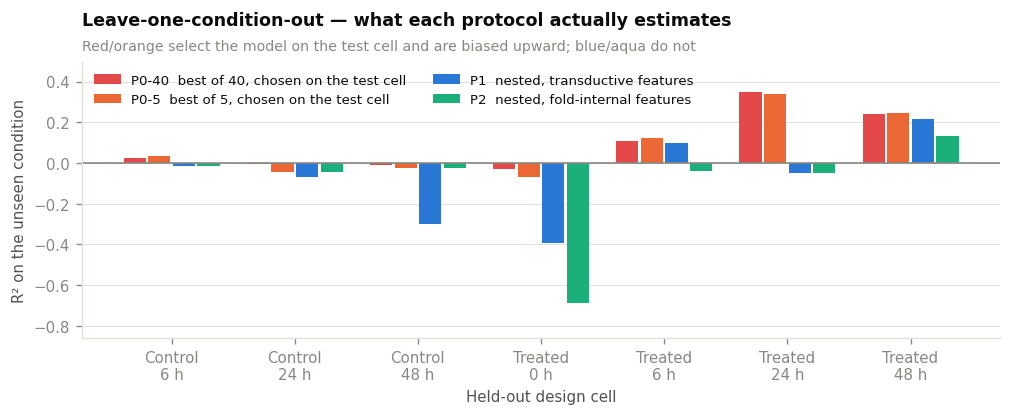

In [31]:
fig, ax = plt.subplots(figsize=(8.6, 3.6))

labels = [f"{r.treatment}\n{r.time_h:.0f} h" for _, r in LOCO2.iterrows()]
xs = np.arange(len(LOCO2))
series = [("p0_40_r2", "P0-40  best of 40, chosen on the test cell", C_RED),
          ("p0_5_r2", "P0-5  best of 5, chosen on the test cell", C_ORANGE),
          ("P1_transductive", "P1  nested, transductive features", C_BLUE),
          ("P2_strict", "P2  nested, fold-internal features", C_AQUA)]
w = 0.2
for i, (col, label, colour) in enumerate(series):
    ax.bar(xs + (i - 1.5) * w, LOCO2[col], width=w * 0.9, color=colour, label=label)

ax.axhline(0, color=MUTED, lw=1)
ax.set_xticks(xs); ax.set_xticklabels(labels)
tidy(ax, xlabel="Held-out design cell",
     ylabel="R² on the unseen condition",
     title="Leave-one-condition-out — what each protocol actually estimates",
     subtitle="Red/orange select the model on the test cell and are biased upward; "
              "blue/aqua do not",
     xgrid=False, ygrid=True)
ax.legend(loc="upper left", fontsize=8, ncol=2)
lo = min(0, LOCO2[[c for c, _, _ in series]].min().min())
ax.set_ylim(lo * 1.25, LOCO2[[c for c, _, _ in series]].max().max() * 1.42)
fig.subplots_adjust(left=0.09, right=0.98, top=0.80, bottom=0.16)
fig.savefig(FIGS / "loco_protocols.png", bbox_inches="tight")
plt.show()

In [32]:
# --- How much did each fix cost? ----------------------------------------
sel_bias = (LOCO2["p0_5_r2"] - LOCO2["P1_transductive"]).mean()
feat_bias = (LOCO2["P1_transductive"] - LOCO2["P2_strict"]).mean()

print("=" * 74)
print("LEAVE-ONE-CONDITION-OUT — effect of each correction (mean over 7 cells)")
print("=" * 74)
for col, name in [("p0_40_r2", "P0-40  best of 40, chosen on test"),
                  ("p0_5_r2", "P0-5   best of 5, chosen on test"),
                  ("P1_transductive", "P1     nested, transductive features"),
                  ("P2_strict", "P2     nested, fold-internal features"),
                  ("dummy_r2", "       predict-the-mean reference")]:
    v = LOCO2[col]
    print(f"  {name:<40s} mean R² = {v.mean():+.3f}   "
          f"(range {v.min():+.3f} to {v.max():+.3f})")
print()
print(f"  Bias from selecting the model on the test cell : {sel_bias:+.3f} R²")
print(f"  Bias from global (transductive) features       : {feat_bias:+.3f} R²")
print()

pos1 = LOCO2[LOCO2.P1_transductive > 0.02]
pos2 = LOCO2[LOCO2.P2_strict > 0.02]
print(f"  Cells with real transductive skill (P1 > 0.02): "
      f"{len(pos1)}/7  {list(pos1.cell)}")
print(f"  Cells with real strict skill        (P2 > 0.02): "
      f"{len(pos2)}/7  {list(pos2.cell)}")
print("=" * 74)

LEAVE-ONE-CONDITION-OUT — effect of each correction (mean over 7 cells)
  P0-40  best of 40, chosen on test        mean R² = +0.098   (range -0.028 to +0.350)
  P0-5   best of 5, chosen on test         mean R² = +0.086   (range -0.069 to +0.337)
  P1     nested, transductive features     mean R² = -0.073   (range -0.391 to +0.215)
  P2     nested, fold-internal features    mean R² = -0.104   (range -0.689 to +0.134)
         predict-the-mean reference        mean R² = -0.036   (range -0.069 to -0.009)

  Bias from selecting the model on the test cell : +0.160 R²
  Bias from global (transductive) features       : +0.031 R²

  Cells with real transductive skill (P1 > 0.02): 2/7  ['T1_t1', 'T1_t3']
  Cells with real strict skill        (P2 > 0.02): 1/7  ['T1_t3']


### Reading §10 — the positive results do not survive

The corrections do not trim the earlier numbers. They erase them.

| Protocol | Mean `R²` | Range |
|:--|:--|:--|
| P0-40 best of 40, chosen on the test cell | **+0.098** | −0.028 … +0.350 |
| P0-5 best of 5, chosen on the test cell | +0.086 | −0.069 … +0.337 |
| P1 nested, transductive features | **−0.073** | −0.391 … +0.215 |
| P2 nested, fold-internal features | **−0.104** | −0.689 … +0.134 |
| predict-the-mean reference | −0.036 | −0.069 … −0.009 |

**Selecting the model on the test cell was worth `+0.160 R²` of pure illusion.**
The single most-quoted number from the first version — `R² = 0.350` at Treated
24 h — becomes **−0.051** once the model is chosen without looking at that cell.
It was not a weak result that got weaker; it was an artefact of taking the
maximum of 40 noisy scores. The transductive-feature leak (Problem 2) costs a
further `+0.031`, real but an order of magnitude smaller. **Problem 1 was the
serious one.**

The most direct evidence is what the inner loop actually chooses. Given only the
training conditions, it picks `DummyRegressor` — predict the mean — for 2 of 7
folds under P1 and **5 of 7 under P2**. When honest inner validation is allowed
to say "nothing here beats the mean", that is usually what it says. And where it
does pick a real model, the held-out score is frequently far *worse* than the
mean (Treated 0 h: −0.391 under P1, −0.689 under P2), which is the signature of a
model confidently extrapolating a relationship that does not hold in the new
condition.

**One result survives.** Treated 48 h is positive under every protocol —
`+0.244` naive, `+0.215` transductive, `+0.134` strict — and it is the only cell
where that is true. Treated 6 h is positive under P1 (`+0.096`) but not P2. So of
seven conditions, one transfers, one is borderline, and five do not.

### What this does and does not overturn

It does **not** touch §6–§7. Those hold genes out while keeping every condition
in training, and there `R² ≈ 0.25` with independent replication in Norin
(`ρ = 0.89`). Predicting **a new protein in a condition the model has seen** is
a genuinely solved problem at that accuracy. The per-condition breakdown in §12
belongs to that regime too.

It **does** overturn any claim about predicting a *new condition*. Those are
different questions, and only the first one works. The earlier version reported
the second while running something closer to the first.

Any figure quoted from this section must now carry its protocol label. P1 is
"fill in protein for a condition that was sequenced but not measured by MS";
P2 is "predict a treatment × timepoint the experiment never ran". They are not
interchangeable, and neither supports a general claim of cross-condition
transfer.

---

## 11. Do treatment and timepoint actually add predictive value?

The brief asked for the prediction to be made *considering the treatments and
timepoints*. §10 asked whether a model can transfer to a condition it has never
seen, and found that it largely cannot. This section asks the complementary
question, inside the regime that does work (all conditions seen, genes held out):
do the condition variables **earn their place** in the feature set, or is the
cognate transcript enough on its own?

We add one feature group at a time and re-score with the same grouped 5-fold CV,
using a single fixed model so that only the feature set varies.

In [33]:
# HistGradientBoostingRegressor is used as the fixed probe for the ablation:
# it is near the top of both leaderboards, handles NaN natively, and — unlike
# NuSVR — scales linearly, so the full dataset can be used rather than a sample.
probe = HistGradientBoostingRegressor(random_state=SEED)

ABLATION_SETS = {
    "1. Cognate RNA only":        ["rna_lfc"],
    "2. + gene context":          ["rna_lfc"] + F_CONTEXT,
    "3. + treatment & timepoint": ["rna_lfc"] + F_CONTEXT + F_CONDITION,
    "4. + kinetics contrasts":    ["rna_lfc"] + F_CONTEXT + F_CONDITION + F_KINETICS,
}

cv = GroupKFold(n_splits=5)
groups = TASK_B["gene"]
y = TASK_B["prot_lfc"]

abl = []
for name, feats in ABLATION_SETS.items():
    # cross_val_predict gives one out-of-fold prediction per row, so the R² below
    # is computed on predictions that never saw their own gene in training.
    oof = cross_val_predict(probe, TASK_B[feats], y, cv=cv, groups=groups)
    abl.append({"feature set": name, "n_features": len(feats),
                "R² (grouped 5-fold)": r2_score(y, oof)})

ABL = pd.DataFrame(abl)
ABL["gain"] = ABL["R² (grouped 5-fold)"].diff().fillna(ABL["R² (grouped 5-fold)"])
ABL.round(4)

,feature set,n_features,R² (grouped 5-fold),gain
0,1. Cognate RNA only,1,0.0504,0.0504
1,2. + gene context,5,0.0659,0.0155
2,3. + treatment & timepoint,7,0.1721,0.1062
3,4. + kinetics contrasts,9,0.2353,0.0632


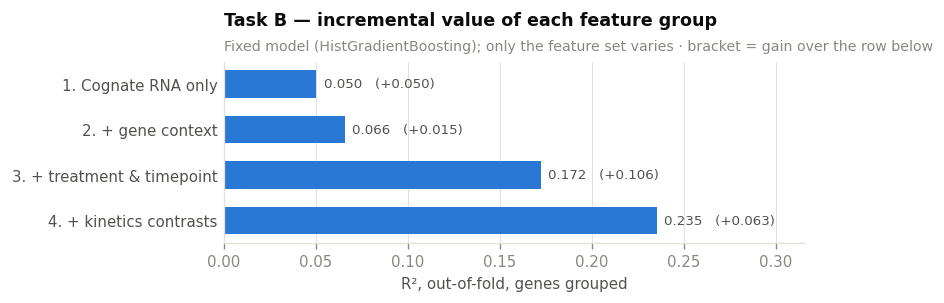

In [34]:
fig, ax = plt.subplots(figsize=(7.2, 2.6))
b = ABL.iloc[::-1]
bars = ax.barh(b["feature set"], b["R² (grouped 5-fold)"], color=C_BLUE, height=0.6)
for bar, v, g in zip(bars, b["R² (grouped 5-fold)"], b["gain"]):
    ax.text(v + 0.004, bar.get_y() + bar.get_height() / 2,
            f"{v:.3f}   ({g:+.3f})", va="center", fontsize=8, color=INK2)
ax.set_xlim(0, ABL["R² (grouped 5-fold)"].max() * 1.34)
tidy(ax, xlabel="R², out-of-fold, genes grouped",
     title="Task B — incremental value of each feature group",
     subtitle="Fixed model (HistGradientBoosting); only the feature set varies · "
              "bracket = gain over the row below")
ax.tick_params(axis="y", length=0, labelcolor=INK2)
fig.tight_layout(); fig.savefig(FIGS / "ablation.png", bbox_inches="tight")
plt.show()

---

## 12. Winner deep-dive

We take the model that topped the Task B gene-split leaderboard and examine it
properly: out-of-fold predictions over the whole dataset, `R²` broken down by
design cell, permutation importance, and a calibration plot.

The winner is reconstructed by **looking its class up in LazyPredict's own
roster**, so this section always analyses whatever actually won rather than a
hard-coded stand-in. It is wrapped in the same `StandardScaler` that LazyPredict
applies internally, so the scores here are comparable to the leaderboard.

The deep-dive runs on a random subsample of **genes** — sampling genes rather
than rows keeps whole genes on one side of the grouped CV, which is what makes
the out-of-fold `R²` honest.

In [35]:
from lazypredict.Supervised import REGRESSORS

WINNER_NAME = BOARD_B.index[0]
print(f"Task B leaderboard winner: {WINNER_NAME}  "
      f"(R² = {BOARD_B['R-Squared'].iloc[0]:.3f})")

# Look the estimator class up by name in LazyPredict's roster, so the deep-dive
# always uses the model that actually won this run.
winner_cls = dict(REGRESSORS)[WINNER_NAME]

# Pass the seed only to estimators that accept one, so the run is reproducible
# without breaking the deterministic models.
kwargs = {"random_state": SEED} if "random_state" in winner_cls().get_params() else {}
model = make_pipeline(StandardScaler(), winner_cls(**kwargs))
print(f"Reconstructed as: {model.steps[-1][1]}")

# Subsample genes to keep the deep-dive tractable, preserving whole genes.
N_GENES_DEEPDIVE = 1500
sel = rng.choice(TASK_B.gene.unique(),
                 size=min(N_GENES_DEEPDIVE, TASK_B.gene.nunique()), replace=False)
DEEP = TASK_B[TASK_B.gene.isin(sel)].copy()
print(f"Deep-dive on {DEEP.gene.nunique():,} genes / {len(DEEP):,} rows")

# Out-of-fold predictions: every row predicted by a model that never saw its gene.
DEEP["pred"] = cross_val_predict(model, DEEP[FEATS_B], DEEP["prot_lfc"],
                                 cv=GroupKFold(n_splits=5), groups=DEEP["gene"])
print(f"Overall out-of-fold R² = {r2_score(DEEP['prot_lfc'], DEEP['pred']):.3f}")

Task B leaderboard winner: GradientBoostingRegressor  (R² = 0.250)
Reconstructed as: GradientBoostingRegressor(random_state=20260826)
Deep-dive on 1,500 genes / 10,194 rows


Overall out-of-fold R² = 0.266


In [36]:
# R² computed WITHIN each design cell. This is the "considering treatments and
# timepoints" breakdown: the same model, scored separately per condition.
per_cell = (DEEP.groupby(["treatment", "time_h", "cell"])
                .apply(lambda g: pd.Series({
                    "n": len(g),
                    "r2": r2_score(g["prot_lfc"], g["pred"]),
                    "pearson_r": g[["prot_lfc", "pred"]].corr().iloc[0, 1],
                    "target_sd": g["prot_lfc"].std(),
                }), include_groups=False)
                .reset_index())
per_cell["treatment"] = per_cell["treatment"].map(TREAT_LABEL)
per_cell = per_cell.sort_values(["treatment", "time_h"])
per_cell.round(3)

,treatment,time_h,cell,n,r2,pearson_r,target_sd
0,Control,6,T0_t1,1455.0,0.038,0.202,0.557
1,Control,24,T0_t2,1440.0,0.015,0.172,0.567
2,Control,48,T0_t3,1472.0,-0.002,0.155,0.576
3,Treated,0,T1_t0,1451.0,-0.037,0.043,0.407
4,Treated,6,T1_t1,1479.0,0.274,0.531,0.701
5,Treated,24,T1_t2,1487.0,0.401,0.637,0.921
6,Treated,48,T1_t3,1410.0,0.355,0.599,1.126


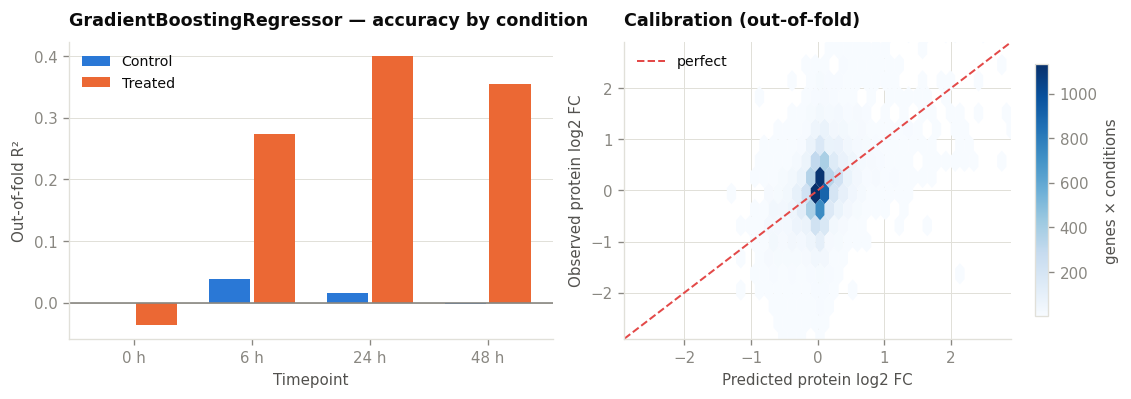

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.4))

# --- left: per-condition R² of the single winning model --------------
ax = axes[0]
times = sorted(per_cell.time_h.unique())
width = 0.38
for i, arm in enumerate(["Control", "Treated"]):
    sub = per_cell[per_cell.treatment == arm].set_index("time_h").reindex(times)
    xs = np.arange(len(times)) + (i - 0.5) * width
    ax.bar(xs, sub["r2"].fillna(0), width=width * 0.92,
           color=TREAT_COLOR[arm], label=arm)
ax.axhline(0, color=MUTED, lw=1)
ax.set_xticks(np.arange(len(times))); ax.set_xticklabels([f"{t} h" for t in times])
tidy(ax, xlabel="Timepoint", ylabel="Out-of-fold R²",
     title=f"{WINNER_NAME} — accuracy by condition", xgrid=False, ygrid=True)
ax.legend(loc="best", fontsize=8.5)

# --- right: calibration, observed vs predicted -----------------------
ax = axes[1]
hb = ax.hexbin(DEEP["pred"], DEEP["prot_lfc"], gridsize=45, mincnt=1,
               cmap="Blues", linewidths=0)
lim = np.percentile(np.abs(pd.concat([DEEP["pred"], DEEP["prot_lfc"]])), 99.5)
ax.plot([-lim, lim], [-lim, lim], color=C_RED, lw=1.2, ls="--", label="perfect")
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
tidy(ax, xlabel="Predicted protein log2 FC", ylabel="Observed protein log2 FC",
     title="Calibration (out-of-fold)", xgrid=True, ygrid=True)
ax.legend(loc="upper left", fontsize=8.5)
fig.colorbar(hb, ax=ax, label="genes × conditions", shrink=0.85)

fig.tight_layout(); fig.savefig(FIGS / "winner_diagnostics.png", bbox_inches="tight")
plt.show()

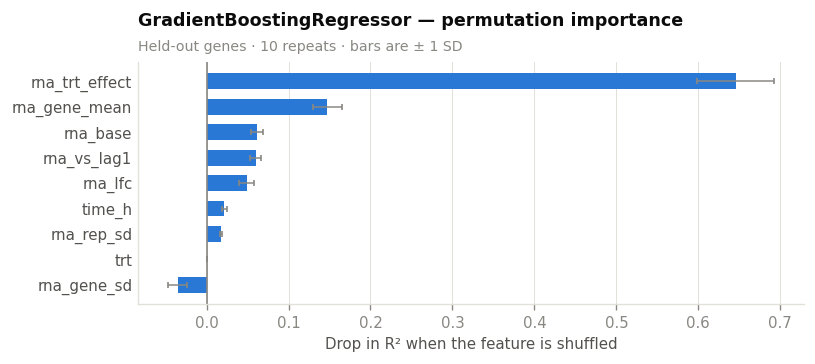

,feature,importance,sd
8,rna_trt_effect,0.6455,0.0465
1,rna_gene_mean,0.1475,0.0175
3,rna_base,0.0615,0.0077
7,rna_vs_lag1,0.0597,0.0068
0,rna_lfc,0.0490,0.0088
6,time_h,0.0218,0.0035
4,rna_rep_sd,0.0177,0.0014
5,trt,0.0000,0.0000
2,rna_gene_sd,-0.0350,0.0114


In [38]:
# Permutation importance: shuffle one feature at a time in the held-out data and
# measure how much R² drops. Model-agnostic, and the standard sklearn routine.
pi_train, pi_test = gene_split(DEEP, test_size=0.3)
fitted = model.fit(pi_train[FEATS_B], pi_train["prot_lfc"])

pi = permutation_importance(fitted, pi_test[FEATS_B], pi_test["prot_lfc"],
                            n_repeats=10, random_state=SEED, scoring="r2", n_jobs=-1)
IMP = (pd.DataFrame({"feature": FEATS_B,
                     "importance": pi.importances_mean,
                     "sd": pi.importances_std})
       .sort_values("importance", ascending=False))

fig, ax = plt.subplots(figsize=(7.6, 3.0))
b = IMP.iloc[::-1]
ax.barh(b["feature"], b["importance"], xerr=b["sd"], color=C_BLUE, height=0.62,
        error_kw=dict(ecolor=MUTED, lw=0.9, capsize=2))
ax.axvline(0, color=MUTED, lw=1)
tidy(ax, xlabel="Drop in R² when the feature is shuffled",
     title=f"{WINNER_NAME} — permutation importance",
     subtitle="Held-out genes · 10 repeats · bars are ± 1 SD")
ax.tick_params(axis="y", length=0, labelcolor=INK2)
# Reserve the left margin explicitly — the feature names are long enough that
# tight_layout alone clips them.
fig.subplots_adjust(left=0.24, right=0.97, top=0.84, bottom=0.17)
fig.savefig(FIGS / "permutation_importance.png", bbox_inches="tight")
plt.show()

IMP.round(4)

---

## 13. Replication in the second variety (Norin)

Everything so far used Cadenza. Norin is an independent experiment with the same
design and its own gene identifiers. If the conclusion is real, the same model
families should win there too. This is a replication, not a merge — the two
varieties are never pooled.

In [39]:
# Rebuild the whole pipeline for Norin using exactly the same functions.
FEATURES_N = build_features("norin")
TASK_B_N = (FEATURES_N[FEATURES_N.cell != BASELINE_CELL]
            .dropna(subset=["prot_lfc"]).copy())
print(f"Norin Task B : {len(TASK_B_N):,} rows | {TASK_B_N.gene.nunique():,} genes")

N_train, N_test = gene_split(TASK_B_N)
BOARD_B_N = sweep(N_train, N_test, FEATS_B, "prot_lfc")
BOARD_B_N.head(10)

Norin Task B : 24,111 rows | 3,556 genes


,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
MLPRegressor,0.289698,0.291296,0.881148,1.000171
HistGradientBoostingRegressor,0.260425,0.262090,0.899121,0.603720
ExtraTreesRegressor,0.238223,0.239938,0.912517,0.745028
RandomForestRegressor,0.226995,0.228734,0.919218,2.438927
SVR,0.214270,0.216038,0.926753,0.652133
NuSVR,0.213079,0.214850,0.927455,0.483408
RidgeCV,0.211290,0.213065,0.928509,0.007442
ElasticNetCV,0.211265,0.213040,0.928523,0.034479
LassoCV,0.211254,0.213029,0.928529,0.034658


Spearman correlation of model rankings across varieties: rho = 0.887

Top 10 in Cadenza, with their Norin scores:
                               Cadenza  Norin
Model                                        
GradientBoostingRegressor        0.250  0.204
MLPRegressor                     0.247  0.291
HistGradientBoostingRegressor    0.241  0.262
RandomForestRegressor            0.227  0.229
NuSVR                            0.220  0.215
SVR                              0.215  0.216
ExtraTreesRegressor              0.212  0.240
LinearRegression                 0.172  0.213
TransformedTargetRegressor       0.172  0.213
LassoLarsCV                      0.172  0.213


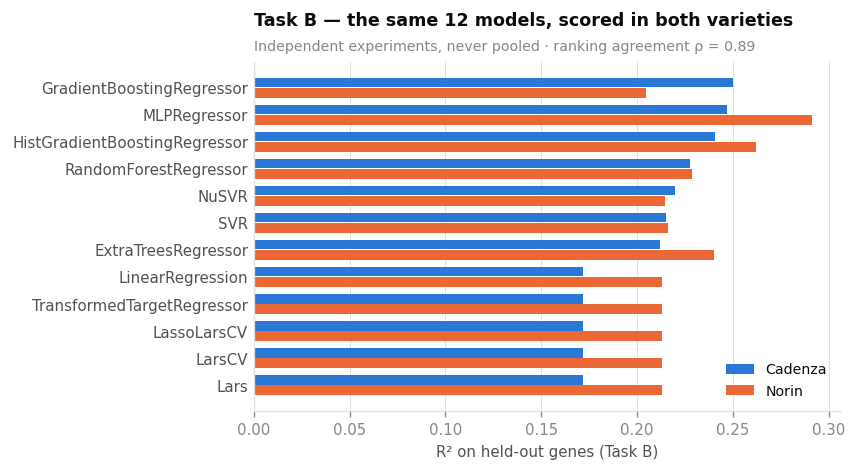

In [40]:
# Do the two varieties agree on which models work?
both = (BOARD_B[["R-Squared"]].rename(columns={"R-Squared": "Cadenza"})
        .join(BOARD_B_N[["R-Squared"]].rename(columns={"R-Squared": "Norin"}))
        .dropna())
rho = both.rank(ascending=False).corr(method="spearman").iloc[0, 1]
print(f"Spearman correlation of model rankings across varieties: rho = {rho:.3f}")
print("\nTop 10 in Cadenza, with their Norin scores:")
print(both.sort_values("Cadenza", ascending=False).head(10).round(3).to_string())

top = both.sort_values("Cadenza", ascending=False).head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(7.2, 4.0))
ys = np.arange(len(top)); h = 0.38
ax.barh(ys + h / 2, top["Cadenza"], height=h * 0.92, color=C_BLUE, label="Cadenza")
ax.barh(ys - h / 2, top["Norin"], height=h * 0.92, color=C_ORANGE, label="Norin")
ax.set_yticks(ys); ax.set_yticklabels(top.index)
ax.axvline(0, color=MUTED, lw=1)
tidy(ax, xlabel="R² on held-out genes (Task B)",
     title="Task B — the same 12 models, scored in both varieties",
     subtitle=f"Independent experiments, never pooled · ranking agreement ρ = {rho:.2f}")
ax.tick_params(axis="y", length=0, labelcolor=INK2)
ax.legend(loc="lower right", fontsize=8.5)
fig.tight_layout(); fig.savefig(FIGS / "variety_replication.png", bbox_inches="tight")
plt.show()

---

## 14. What is safe to claim

*(The numbers referenced below are printed in the summary cell that follows, so
this section stays consistent with whatever the last run produced.)*

**On the framing.** Under the Case B design the design cell is the only
legitimate pairing unit, so "predict protein from RNA" becomes a supervised
problem over (gene × design cell) rows. That framing gives tens of thousands of
observations instead of 8 pseudo-samples, which is what makes a 40-model screen
meaningful at all.

**On the models.** No single algorithm wins decisively, but the screen is very
consistent about *shape*. A tight group — the boosted-tree ensembles
(`GradientBoosting`, `HistGradientBoosting`, `RandomForest`, `ExtraTrees`), the
kernel SVMs (`NuSVR`, `SVR`) and `MLPRegressor` — sits around `R² ≈ 0.21–0.25`,
clearly above the best linear model at `≈ 0.17`, which is clearly above
`DummyRegressor` at `0`. The order *within* that top group shuffles between
varieties, so the defensible claim is **"a non-linear learner, family not
critical"**, not "model X is best". The ~0.08 gap over the linear fit is the real,
reproducible finding: the RNA→protein map has non-linear structure worth
modelling. Two models genuinely fail — `GaussianProcessRegressor` and
`KernelRidge` at their scikit-learn defaults — which is a statement about default
hyperparameters at this feature scale, not about the method class.

**On replication.** The two varieties agree on the model ranking at Spearman
`ρ ≈ 0.89`, with very similar top scores, from completely independent
experiments and disjoint gene identifiers. That is the strongest evidence here
that the signal is real rather than a fitting artefact.

**On the biology.** Task A's `R²` is inflated by gene identity and should not be
quoted as "RNA explains X% of protein". Task B is the honest number, and it sits
in the range the literature reports for mRNA→protein fold-change agreement.

The ablation in §11 is the direct answer to *"considering the treatments and
timepoints"*: the cognate transcript alone reaches only `R² ≈ 0.05`; adding
**treatment and timepoint is the single largest gain in the whole feature set**
(`+0.106`), and the kinetic contrasts add a further `+0.063`. Condition is not a
nuisance covariate to be regressed out here — it is most of the predictive
signal, and a model of this data that ignores the design would forfeit roughly
three quarters of what is predictable.

**How that condition information is best supplied is a separate, sharper point.**
Permutation importance on the final model is dominated by a single feature —
`rna_trt_effect`, the transcript's treated-minus-matched-control contrast — at
roughly four times the next feature. The raw indicators are near-worthless *in
that model*: `time_h` scores ≈ 0.02 and `trt` exactly 0.00. Those two facts are
not in conflict. `rna_trt_effect` already carries the treatment comparison, in
transcript units, so once it is present the raw labels are redundant. The
practical lesson is that the design should enter the model as an **RNA-side
contrast**, not as a categorical covariate. `rna_gene_sd` scoring slightly
negative is the ordinary sign of a feature contributing nothing but noise.

**On the baseline — the largest single effect in the notebook.** §8 shows the
reference scheme moves `R²` from 0.235 to 0.422, with non-overlapping CIs. That
is a bigger effect than the choice of algorithm, and bigger than every feature
group in §11 put together. **What protein is measured relative to matters more
than what model is fitted to it.**

The winning scheme is `matched_ctrl` — treated minus its *same-timepoint*
control. It is the only one that removes both the gene's constitutive level and
whatever happened over 48 h that was not the treatment. That is the quantitative
case for running a parallel control arm, and it is worth about `+0.17 R²`.

Referencing is not automatically good, though: `global_t0` (everything centred on
Control / t = 0) is the *worst* scheme tested, below no referencing at all. A
reference helps when it is matched to the nuisance being removed; an unmatched
one subtracts a single noisy measurement from every row and removes nothing. The
useful generalisation is **"reference against a matched control"**, not
"difference against something".

**On the RNA universe — a licensed simplification.** §9 finds no detectable
difference between normalising over the full ~128k transcriptome and over the
~6k protein-matched subset (`ΔR² = +0.006`, `p = 0.33`), and adding co-expression
features built from genes whose protein is never measured changes nothing
(`−0.003`, `p = 0.99`). Given that the same machinery resolved §8's `0.187`
cleanly, this is a reasonably powered negative. The analysis can be run on the
matched subset alone. This tests *co-expression* trans features; a targeted
regulator or pathway hypothesis is a different question and is not excluded.

**The important negative result — cross-condition transfer does not work.**
§10 replaces an earlier, badly overstated version of this claim. Selecting the
best of 40 models *on the held-out condition* inflated the estimate by
`+0.160 R²`; the headline `R² = 0.350` at Treated 24 h becomes **−0.051** once
the model is chosen without consulting that cell. Under honest nested selection
the mean across conditions is **−0.073** (transductive features) and **−0.104**
(fold-internal), against `−0.036` for predicting the mean. Inner validation picks
`DummyRegressor` for 5 of 7 folds under the strict protocol, which is the
clearest possible statement that there is nothing there to learn.

Exactly one condition survives every protocol: **Treated 48 h** (`+0.215`
transductive, `+0.134` strict). One of seven.

**Keep the two questions apart.** Nothing above weakens §6–§7. Holding out
*genes* while keeping all conditions in training gives `R² ≈ 0.25`, replicated
independently in Norin at `ρ = 0.89`. Predicting a **new protein in a known
condition** works. Predicting a **new condition** does not. The per-condition
`R²` in §12 — 0.40 at Treated 24 h — belongs to the first regime and must not be
quoted as evidence for the second.

**What would strengthen this.**

1. Hyperparameter tuning — LazyPredict scores *defaults*. The ranking identifies
   promising families; it does not establish the best achievable accuracy.
2. Nested CV for the §12 deep-dive as well, so that model selection and
   evaluation are separated there too rather than both resting on the §7 split.
   §10 now does this; §12 does not.
3. A permutation null for the LOCO `R²` values, matching the treatment the
   existing `Q²` analysis gives them in `R/06_integration_caseB.R`.
4. Re-running §10 under the `matched_ctrl` representation on its four treated
   conditions. §8 says it is the most learnable target; §10 could not use it
   because it dissolves the control arm into the reference, but a treated-only
   LOCO would be a fairer test of the best-supported framing.
5. Sequence- and annotation-derived features (codon usage, predicted half-life,
   MapMan functional bin) — the notebook currently uses RNA and design only.

In [41]:
# --- Summary printed from the objects actually computed above -----------
print("=" * 74)
print("SUMMARY — predicting protein from RNA-seq (Cadenza primary, Norin replication)")
print("=" * 74)
print(f"Design cells                : {TASK_A.cell.nunique()} (2 treatments x 4 timepoints)")
print(f"Task A rows / genes         : {len(TASK_A):,} / {TASK_A.gene.nunique():,}")
print(f"Task B rows / genes         : {len(TASK_B):,} / {TASK_B.gene.nunique():,}")
print()
print(f"Task A best  : {BOARD_A.index[0]:<30s} R² = {BOARD_A['R-Squared'].iloc[0]:.3f}")
print(f"Task B best  : {BOARD_B.index[0]:<30s} R² = {BOARD_B['R-Squared'].iloc[0]:.3f}")
print(f"Task B best (Norin)          : {BOARD_B_N.index[0]:<20s} "
      f"R² = {BOARD_B_N['R-Squared'].iloc[0]:.3f}")
print(f"Best linear model (Task B)   : "
      f"{BOARD_B.loc[['LinearRegression','RidgeCV','ElasticNetCV']].sort_values('R-Squared', ascending=False).index[0]:<20s} "
      f"R² = {BOARD_B.loc[['LinearRegression','RidgeCV','ElasticNetCV'],'R-Squared'].max():.3f}")
print(f"DummyRegressor (Task B)      : R² = {BOARD_B.loc['DummyRegressor','R-Squared']:.3f}")
print()
print("Baseline / reference scheme (§8):")
for _, r in BASELINE_STUDY.iterrows():
    note = "   <- leaky, not a candidate" if r.scheme == "gene_mean" else ""
    print(f"   {r.scheme:<14s} R² = {r.R2:.3f}  [{r.ci_lo:.3f}, {r.ci_hi:.3f}]{note}")
for _, r in CMP.iterrows():
    sig = (r.ci_lo * r.ci_hi > 0) and (r.wilcoxon_p < 0.05)
    print(f"   {r.comparison:<48s} ΔR² = {r.delta_r2:+.4f}  "
          f"{'SIGNIFICANT' if sig else 'n.s.'}")
print()
print("RNA universe (§9):")
for _, r in UNIVERSE_STUDY.iterrows():
    print(f"   {r['arm']:<32s} R² = {r.R2:.4f}  [{r.ci_lo:.4f}, {r.ci_hi:.4f}]")
for _, r in CMP9.iterrows():
    sig = (r.ci_lo * r.ci_hi > 0) and (r.wilcoxon_p < 0.05)
    print(f"   {r.comparison:<52s} ΔR² = {r.delta_r2:+.4f}  "
          f"{'SIGNIFICANT' if sig else 'n.s.'}")
print()
print("Leave-one-condition-out (§10), by protocol:")
print(f"   {'cell':<8s} {'P0-40':>7s} {'P0-5':>7s} {'P1 trans':>9s} "
      f"{'P2 strict':>10s}   chosen (P2)")
for _, r in LOCO2.iterrows():
    print(f"   {r.cell:<8s} {r.p0_40_r2:>+7.3f} {r.p0_5_r2:>+7.3f} "
          f"{r.P1_transductive:>+9.3f} {r.P2_strict:>+10.3f}   {r.P2_model}")
print(f"   {'MEAN':<8s} {LOCO2.p0_40_r2.mean():>+7.3f} {LOCO2.p0_5_r2.mean():>+7.3f} "
      f"{LOCO2.P1_transductive.mean():>+9.3f} {LOCO2.P2_strict.mean():>+10.3f}")
print(f"   selection bias {sel_bias:+.3f} R² | transductive-feature bias {feat_bias:+.3f} R²")
print()
print("Feature ablation (Task B, grouped 5-fold, fixed HistGradientBoosting):")
for _, r in ABL.iterrows():
    print(f"   {r['feature set']:<28s} R² = {r['R² (grouped 5-fold)']:.3f}   "
          f"gain {r['gain']:+.3f}")
print()
print(f"Top 3 permutation-importance features: "
      f"{', '.join(IMP.head(3).feature)}")
print(f"Cross-variety ranking agreement: Spearman rho = {rho:.3f}")
print("=" * 74)

SUMMARY — predicting protein from RNA-seq (Cadenza primary, Norin replication)
Design cells                : 8 (2 treatments x 4 timepoints)


Task A rows / genes         : 30,278 / 3,926
Task B rows / genes         : 25,154 / 3,707

Task A best  : NuSVR                          R² = 0.251
Task B best  : GradientBoostingRegressor      R² = 0.250
Task B best (Norin)          : MLPRegressor         R² = 0.291
Best linear model (Task B)   : LinearRegression     R² = 0.172
DummyRegressor (Task B)      : R² = -0.002

Baseline / reference scheme (§8):
   matched_ctrl   R² = 0.422  [0.375, 0.464]
   gene_mean      R² = 0.332  [0.292, 0.363]   <- leaky, not a candidate
   arm_t0         R² = 0.296  [0.252, 0.340]
   absolute       R² = 0.256  [0.218, 0.290]
   global_t0      R² = 0.235  [0.192, 0.270]
   Referenced RNA vs Absolute RNA  (full feature set) ΔR² = +0.0032  n.s.
   Referenced RNA vs Absolute RNA  (cognate predictor alone) ΔR² = +0.0201  SIGNIFICANT

RNA universe (§9):
   matched (~6k gene universe)      R² = 0.2297  [0.1852, 0.2629]
   full (~128k gene universe)       R² = 0.2353  [0.1917, 0.2701]
   full + trans co-expre